# The variational quantum eigensolver — ground states of spin chains from a trained circuit

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

The central computational problem of quantum many-body physics is the **ground state**: the eigenvector of the
Hamiltonian with the lowest eigenvalue. Magnetic order, superconductivity, the binding energy of a molecule and the
phase diagram of a spin chain are all read off from it. Exact diagonalisation gives it for $N\lesssim20$ spins and
then stops, because the Hilbert-space dimension is $2^N$.

The **variational quantum eigensolver** (VQE) is one answer to that wall. It replaces the eigenvalue problem by a
minimisation: pick a family of states $\vert\psi(\boldsymbol\theta)\rangle$ that a quantum device can prepare, measure
the energy $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle$, and let a
classical optimiser push $\boldsymbol\theta$ downhill. The variational principle guarantees that whatever the optimiser
finds is an upper bound on the true ground energy $E_0$, so the method cannot lie in the dangerous direction: it can
only be *too high*.

```text
    |0...0>  --->  U(theta)  --->  |psi(theta)>  --->  measure <H>  --->  E(theta)
                       ^                                                    |
                       +------------- classical optimiser <-----------------+
```

This was the first algorithm run on quantum hardware in this style (Peruzzo *et al.*, 2014, on a photonic chip), the
first to be scaled to a handful of superconducting qubits (Kandala *et al.*, 2017), and it remains the most studied
application of noisy intermediate-scale devices (Tilly *et al.*, 2022).

**What this notebook does.** We run the complete algorithm on a simulator, where the exact answer is available from
Lanczos, and we ask the questions that only a simulator can answer:

* the energy converges — but does the **state**? We derive and then measure the two inequalities that connect the
  energy error to the fidelity, and find that the energy error is *second order* in the state error while being bounded
  below by (gap) $\times$ (infidelity);
* the Hamiltonians have a symmetry; the ansatz does not. We measure how much symmetry the optimised state leaks;
* how does the error depend on the number of layers, and is the limit expressivity or trainability?
* across the phase diagram of the transverse-field Ising chain, where is VQE hard — and what does "fidelity" even mean
  in a phase with a nearly degenerate ground doublet?
* how does one get an *excited* state out of a method built to minimise?
* with a finite measurement budget, which optimiser gets further per shot?

**Road map.** Section 3 proves the variational principle and the two error relations, and measures them. Section 4
fixes the three Hamiltonians and their exact references. Section 5 treats symmetry. Sections 6 to 8 build and run the
VQE loop and produce the nine-panel metric comparison against the exact ground state. Sections 9 to 13 are the studies:
symmetry leakage, depth, the phase diagram, deflation for the first excited state, and shot noise at equal budget.
Section 14 states the limits honestly.

### What you will learn

*Physics*

* the Rayleigh-Ritz variational principle with its proof, and why it makes an upper bound on $E_0$ free;
* why an energy accurate to $10^{-3}$ can come with a state whose fidelity is $0.7$, and why the reverse cannot happen:
  $E-E_0\ge\Delta\,(1-F)$ with $\Delta$ the spectral gap;
* what a $\mathbb Z_2$ symmetry of a spin chain is, why the hardware-efficient ansatz breaks it, and what
  symmetry breaking means for a finite chain with an exponentially small gap;
* the physics of the transverse-field Ising chain across its transition: entanglement peaks at the critical point,
  the gap closes in the ordered phase, and a variational state can have a tiny energy error and fidelity $\approx1/2$.

*Numerical methods*

* the VQE loop as a compiled `lax.scan` with statistics over random initialisations, never a single run;
* variational quantum deflation: an orthogonality penalty that turns a minimiser into an excited-state solver, and the
  condition on the penalty strength;
* the entanglement a depth-$L$ nearest-neighbour circuit can carry across a cut, derived as a bound and measured;
* a fair comparison of gradient methods at equal *measurement budget* rather than at equal iteration count.

*Implementation practice*

* making the Hamiltonian coefficients **traced** arguments so that one compiled program serves three models, or a
  whole magnetic-field sweep;
* a vector-valued `monitor` inside the training scan, so that nine physical observables are recorded per iteration at
  the cost of one compilation;
* validating every reference: Lanczos against dense diagonalisation, matrix-free energies against explicit matrix
  elements, and a symmetry against a matrix-free commutator.

### Prerequisites

* [40 — parametrized gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb):
  ansätze, cost functions, the parameter-shift rule, SPSA, `jax.grad` through a circuit, barren plateaus;
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): Adam, SPSA with Spall gains, the
  `lax.scan` training loop, `vmap` over random initialisations, and the overparametrisation threshold;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Hamiltonians as lists of local terms, and the Lanczos ground state that is our reference throughout;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, entanglement entropy, fidelity.

**Conventions and sizes.** Qubit $q$ is tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. Hamiltonians
are written in the Pauli convention (Section 4.1), never with spin-$1/2$ operators. The main studies use $N=6$ spins so
that twelve random restarts times three models times three hundred iterations fit into one compiled program; the
shot-noise study uses $N=4$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the gate application and rotations, the hardware-efficient ansatz with its parameter count,
the Hamiltonian machinery (`heisenberg_terms`, `energy`, `dense_hamiltonian`, `lanczos_ground_state`), the state
characteristics (`entanglement_entropy`, `fidelity_pure`, `all_local_expectations`, `expect_pauli_string`) and
`sample_bitstrings` for the shot-noise section. The optimiser and training-loop helpers are the ones built in
[41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb) and are repeated here so that this notebook
runs on its own.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for PP in {XX, YY, ZZ}.

    Because (P x P)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def parameter_shift_grad(f, theta, shift=jnp.pi / 2):
    """Parameter-shift rule: for gates exp(-i theta_k P/2) with P^2 = 1 the cost is a sinusoid in theta_k, so
        d f / d theta_k = [ f(theta + (pi/2) e_k) - f(theta - (pi/2) e_k) ] / 2        (EXACT, not finite differences)
    -- the gradient a real quantum computer can measure: 2 circuit evaluations per parameter.
    JAX: vmap over the unit vectors e_k evaluates all shifted circuits in one batched call."""
    eye = jnp.eye(theta.size).reshape((theta.size,) + theta.shape)
    return jax.vmap(lambda e: (f(theta + shift * e) - f(theta - shift * e)) / 2)(eye).reshape(theta.shape)

def spsa_grad(key, f, theta, c=0.1):
    """SPSA gradient estimate (Spall 1992): perturb ALL parameters at once along a random +-1 direction Delta,
        g = [f(theta + c Delta) - f(theta - c Delta)] / (2c) * Delta        (Delta_k^{-1} = Delta_k)
    Two evaluations regardless of the number of parameters; unbiased up to O(c^2); noisy but cheap --
    the method of choice for shot-noise-limited / stochastic cost functions."""
    delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
    return (f(theta + c * delta) - f(theta - c * delta)) / (2 * c) * delta

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + the optimiser / training helpers of notebook 41
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def bands(hist):
    """Median and interquartile band of a batch of histories, shape (n_runs, n_steps) -> three curves."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def iterations_to(hist, target):
    """First iteration (1-based) at which the monitored quantity falls below `target`; -1 if it never does."""
    h = np.asarray(hist)
    below = h < target
    first = np.argmax(below, axis=1) + 1
    return np.where(below.any(axis=1), first, -1)


def summarise(name, hist, target, evals_per_iter):
    """One row of a benchmark table: success rate, median iterations and median circuit evaluations to `target`."""
    it = iterations_to(hist, target)
    ok = it > 0
    med = float(np.median(it[ok])) if ok.any() else float("nan")
    return dict(name=name, success=float(ok.mean()), iters=med, evals=med * evals_per_iter,
                best=float(np.min(np.asarray(hist)[:, -1])), median_final=float(np.median(np.asarray(hist)[:, -1])))


def opt_adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam as an (init, update) pair -- the optimiser interface of notebook 41.  State: (m, v)."""
    def init(theta):
        return (jnp.zeros_like(theta), jnp.zeros_like(theta))

    def update(theta, state, g, k):
        m, v = state
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        return theta - lr * (m / (1 - b1 ** k)) / (jnp.sqrt(v / (1 - b2 ** k)) + eps), (m, v)

    return init, update


def train(theta0, key, grad_rule, opt, monitor, n_steps):
    """One training run compiled as a single `lax.scan` (notebook 41, Section 10).

    ARGUMENTS
    ---------
    grad_rule(theta, key, k) -> gradient estimate     (exact AD, SPSA, parameter shift with shots, ...)
    opt = (init(theta), update(theta, state, g, k))   -> (theta, state)
    monitor(theta) -> ANY pytree recorded after every update; here a vector of nine physical observables.
    JAX  the loop counter is the scan's `xs`, so Adam's bias correction and Spall's gain schedules compile
         into the body instead of forcing a Python loop.
    """
    init_fn, update_fn = opt

    def body(carry, k):
        theta, state, key = carry
        key, sub = jax.random.split(key)
        g = grad_rule(theta, sub, k)
        theta, state = update_fn(theta, state, g, k)
        return (theta, state, key), monitor(theta)

    (theta, _, _), hist = lax.scan(body, (theta0, init_fn(theta0), key), jnp.arange(1, n_steps + 1))
    return theta, hist


def train_many(thetas, keys, grad_rule, opt, monitor, n_steps):
    """`train` vmapped over a batch of initial parameter vectors and keys -> (thetas, histories)."""
    return jax.jit(jax.vmap(lambda t, k: train(t, k, grad_rule, opt, monitor, n_steps)))(thetas, keys)


def random_starts(n_runs, n_params, seed, scale=jnp.pi):
    """`n_runs` independent parameter vectors drawn uniformly from [-scale, scale]^n, plus one PRNG key each."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    return (jax.random.uniform(k1, (n_runs, n_params), minval=-scale, maxval=scale),
            jax.random.split(k2, n_runs))


def grad_exact(cost):
    """Exact gradient rule: reverse-mode AD, ignoring the key and the iteration counter."""
    gfn = jax.grad(cost)
    return lambda theta, key, k: gfn(theta)


def grad_spsa(cost, c=0.2, gamma=0.101):
    """SPSA gradient rule with Spall's probe radius c_k = c / k^gamma (notebook 41, Section 7)."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
        return (cost(theta + c_k * delta) - cost(theta - c_k * delta)) / (2 * c_k) * delta
    return rule

## 3. The variational principle, and how energy error relates to state error

### 3.1 The Rayleigh-Ritz bound

Let $H$ be Hermitian with eigenvalues $E_0\le E_1\le\dots\le E_{d-1}$ and orthonormal eigenvectors
$\vert n\rangle$, $d=2^N$. Take **any** normalised state and expand it in that basis,

$$\vert\psi\rangle=\sum_{n=0}^{d-1}c_n\vert n\rangle,\qquad \sum_n\lvert c_n\rvert^2=1 .$$

Then

$$\langle\psi\vert H\vert\psi\rangle=\sum_{n,m}\overline{c_m}c_n\langle m\vert H\vert n\rangle
  =\sum_{n}\lvert c_n\rvert^2E_n\;\ge\;\sum_n\lvert c_n\rvert^2E_0=E_0 , \tag{1}$$

because $E_n\ge E_0$ for every $n$ and the weights $\lvert c_n\rvert^2$ are non-negative and sum to one. Equality
requires $\lvert c_n\rvert^2(E_n-E_0)=0$ for every $n$, i.e. all the weight sits on the ground eigenspace. This is the
**Rayleigh-Ritz principle**: the energy of any trial state is an upper bound on $E_0$, saturated exactly on a ground
state. Nothing in the argument used that the trial state comes from a circuit, so it applies to every ansatz, every
optimiser and every stage of the optimisation. It also gives a free correctness test for the whole implementation: a
measured $E(\boldsymbol\theta)<E_0$ is a bug, never a discovery.

### 3.2 The energy error is second order in the state error

Write the trial state as the exact ground state plus a small orthogonal admixture,

$$\vert\psi\rangle=\frac{\vert\psi_0\rangle+\varepsilon\vert\delta\rangle}{\sqrt{1+\varepsilon^2}},
  \qquad\langle\psi_0\vert\delta\rangle=0,\ \langle\delta\vert\delta\rangle=1 .$$

The energy is

$$\begin{aligned}
E&=\frac{\langle\psi_0\vert H\vert\psi_0\rangle+2\varepsilon\,\mathrm{Re}\langle\psi_0\vert H\vert\delta\rangle
    +\varepsilon^2\langle\delta\vert H\vert\delta\rangle}{1+\varepsilon^2}\\
 &=\frac{E_0+2\varepsilon E_0\,\mathrm{Re}\langle\psi_0\vert\delta\rangle+\varepsilon^2\langle\delta\vert H\vert\delta\rangle}
        {1+\varepsilon^2}
  =\frac{E_0+\varepsilon^2\langle\delta\vert H\vert\delta\rangle}{1+\varepsilon^2},
\end{aligned}$$

where the cross term vanished because $\langle\psi_0\vert H=E_0\langle\psi_0\vert$ and $\langle\psi_0\vert\delta\rangle=0$.
Subtracting $E_0$,

$$E-E_0=\frac{\varepsilon^{2}}{1+\varepsilon^{2}}\bigl(\langle\delta\vert H\vert\delta\rangle-E_0\bigr)
  =O(\varepsilon^{2}). \tag{2}$$

The *state* error is first order in $\varepsilon$; the *energy* error is second order. A variational energy that is
correct to eight digits may come from a state that is wrong in the third. This is the oldest and most useful fact
about variational calculations, and it cuts both ways: energies converge fast, everything else does not.

### 3.3 Two-sided bounds in terms of the fidelity

Equation (2) is about a specific perturbation. The statement that holds for *every* trial state uses only the weights
of Eq. (1). Define the fidelity with the ground state, $F=\lvert\langle\psi_0\vert\psi\rangle\rvert^2=\lvert c_0\rvert^2$
(assume for the moment that $E_0$ is non-degenerate). Then

$$E-E_0=\sum_{n\ge1}\lvert c_n\rvert^{2}\,(E_n-E_0). \tag{3}$$

Every term of Eq. (3) has $E_n-E_0\ge E_1-E_0\equiv\Delta$, the **spectral gap**, and
$\sum_{n\ge1}\lvert c_n\rvert^2=1-F$. Bounding the bracket from below by $\Delta$ and from above by
$E_{\max}-E_0$ gives

$$\boxed{\;\Delta\,(1-F)\;\le\;E-E_0\;\le\;(E_{\max}-E_0)\,(1-F)\;}\tag{4}$$

Read the left inequality as a *guarantee*: an energy error below $\Delta(1-F)$ is impossible, so

$$1-F\;\le\;\frac{E-E_0}{\Delta} \tag{5}$$

converts a measured energy error into a certified bound on the infidelity — the only way to say anything about the
state when the exact state is unknown, which on hardware it always is. Read the right inequality as a *warning*: the
same infidelity is compatible with an energy error larger by the factor $(E_{\max}-E_0)/\Delta$, which for a critical
chain is large.

Equation (4) also explains why a small gap is doubly bad. A gapless (or nearly degenerate) system has
$\Delta\to0$, so Eq. (5) certifies nothing: the energy can be converged to machine precision while the state is
anything at all inside the near-degenerate subspace. Section 11 shows exactly that happening.

### 3.4 Measuring Eqs. (2) and (4)

We take the exact ground state of a test Hamiltonian, mix in a fixed random orthogonal direction with amplitude
$\varepsilon$, and plot the energy error against the infidelity $1-F$ over six decades, together with both bounds of
Eq. (4).

TFIM N=6, h=1: E_0 = -7.296230, gap Delta = 0.482147, E_max - E_0 = 14.592460
orthogonality of the perturbation direction: |<psi_0|delta>| = 2.50e-17



   epsilon        1 - F      E - E_0   lower bound   upper bound   (E-E0)/eps^2
  1.00e-04    1.000e-08    7.210e-08     4.821e-09     1.459e-07       7.209637
  1.00e-03    1.000e-06    7.210e-06     4.821e-07     1.459e-05       7.209630
  1.00e-02    9.999e-05    7.209e-04     4.821e-05     1.459e-03       7.208916
  1.00e-01    9.901e-03    7.138e-02     4.774e-03     1.445e-01       7.138254
  1.00e+00    5.000e-01    3.605e+00     2.411e-01     7.296e+00       3.604818


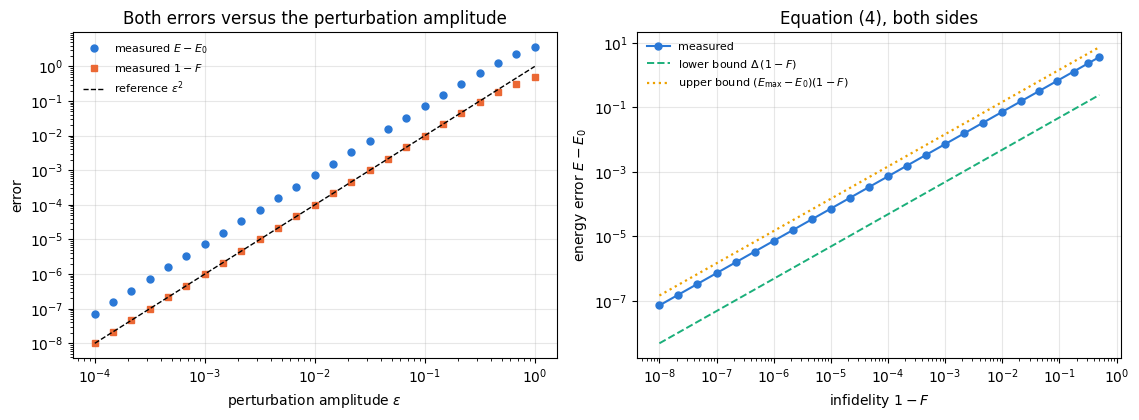

In [4]:
# ==============================================================================
# STEP 1: the energy error versus the state error, for a controlled perturbation
# ==============================================================================
N_PERT = 6
terms_pert = heisenberg_terms(N_PERT, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=1.0)      # TFIM at its critical field
H_dense = np.asarray(dense_hamiltonian(terms_pert, N_PERT))
w_pert, V_pert = np.linalg.eigh(H_dense)
E0_pert, E1_pert, Emax_pert = float(w_pert[0]), float(w_pert[1]), float(w_pert[-1])
gap_pert = E1_pert - E0_pert
psi0_pert = jnp.asarray(V_pert[:, 0], dtype=CDTYPE).reshape((2,) * N_PERT)

# a normalised direction orthogonal to the ground state: project a Haar-random state
delta = haar_state(jax.random.PRNGKey(3), N_PERT)
delta = delta - jnp.vdot(psi0_pert, delta) * psi0_pert
delta = delta / jnp.linalg.norm(delta)
print(f"TFIM N={N_PERT}, h=1: E_0 = {E0_pert:.6f}, gap Delta = {gap_pert:.6f}, E_max - E_0 = {Emax_pert - E0_pert:.6f}")
print(f"orthogonality of the perturbation direction: |<psi_0|delta>| = {float(jnp.abs(jnp.vdot(psi0_pert, delta))):.2e}")

eps_grid = np.logspace(-4, 0, 25)
rows_pert = []
for eps in eps_grid:
    psi = (psi0_pert + eps * delta) / jnp.sqrt(1.0 + eps ** 2)
    dE = float(energy(terms_pert, psi)) - E0_pert
    inf = 1.0 - float(fidelity_pure(psi0_pert, psi))
    rows_pert.append((eps, inf, dE))
rows_pert = np.array(rows_pert)

print(f"\n{'epsilon':>10s} {'1 - F':>12s} {'E - E_0':>12s} {'lower bound':>13s} {'upper bound':>13s} {'(E-E0)/eps^2':>14s}")
for r in rows_pert[::6]:
    print(f"{r[0]:10.2e} {r[1]:12.3e} {r[2]:12.3e} {gap_pert * r[1]:13.3e} "
          f"{(Emax_pert - E0_pert) * r[1]:13.3e} {r[2] / r[0] ** 2:14.6f}")
assert np.all(rows_pert[:, 2] >= gap_pert * rows_pert[:, 1] - 1e-12)
assert np.all(rows_pert[:, 2] <= (Emax_pert - E0_pert) * rows_pert[:, 1] + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].loglog(rows_pert[:, 0], rows_pert[:, 2], MARKERS[0], ms=5, color=PALETTE[0], label=r"measured $E-E_0$")
axes[0].loglog(rows_pert[:, 0], rows_pert[:, 1], MARKERS[1], ms=4, color=PALETTE[1], label=r"measured $1-F$")
axes[0].loglog(rows_pert[:, 0], rows_pert[:, 0] ** 2, "k--", lw=1, label=r"reference $\varepsilon^2$")
axes[0].set_xlabel(r"perturbation amplitude $\varepsilon$"); axes[0].set_ylabel("error")
axes[0].set_title("Both errors versus the perturbation amplitude"); axes[0].legend(fontsize=8)

axes[1].loglog(rows_pert[:, 1], rows_pert[:, 2], MARKERS[0] + "-", ms=5, color=PALETTE[0], label=r"measured")
axes[1].loglog(rows_pert[:, 1], gap_pert * rows_pert[:, 1], "--", color=PALETTE[2], lw=1.4,
               label=r"lower bound $\Delta\,(1-F)$")
axes[1].loglog(rows_pert[:, 1], (Emax_pert - E0_pert) * rows_pert[:, 1], ":", color=PALETTE[3], lw=1.6,
               label=r"upper bound $(E_{\max}-E_0)(1-F)$")
axes[1].set_xlabel(r"infidelity $1-F$"); axes[1].set_ylabel(r"energy error $E-E_0$")
axes[1].set_title("Equation (4), both sides"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The measurement reproduces both derivations exactly.

**Equation (2).** The last column is $(E-E_0)/\varepsilon^2$, and it is constant at $7.2096$ over the two decades
from $\varepsilon=10^{-4}$ to $10^{-2}$. That constant is nothing else than
$\langle\delta\vert H\vert\delta\rangle-E_0$, the energy of the admixed direction measured from the ground energy;
at $\varepsilon=1$ the prefactor $\varepsilon^2/(1+\varepsilon^2)=1/2$ reduces it to $3.6048$, exactly half, as the
denominator of Eq. (2) requires. The infidelity behaves as $1-F=\varepsilon^2/(1+\varepsilon^2)$: $10^{-8}$ at
$\varepsilon=10^{-4}$ and $0.5$ at $\varepsilon=1$.

**The practical consequence.** At $\varepsilon=10^{-2}$ the state has infidelity $10^{-4}$ and the energy error is
$7.2\cdot10^{-4}$ out of a total energy of $-7.296$ — a *relative* energy error of $10^{-4}$ while the state is wrong
at the $1\%$ level in amplitude. Quoting a variational energy to five digits says nothing about the state having
five correct digits.

**Equation (4).** The right panel shows the measured relation $E-E_0=7.2096\,(1-F)$ as a straight line of slope one,
lying between the two bounds at every point: the lower bound $\Delta(1-F)=0.482\,(1-F)$ and the upper bound
$(E_{\max}-E_0)(1-F)=14.59\,(1-F)$. The two bounds differ by a factor $(E_{\max}-E_0)/\Delta=30$ here, which is the
width of the window that a measured energy error leaves for the infidelity. A gapless system would make that window
infinite; Section 11 measures one.

> **Numerical practice.** The perturbation direction was built by projecting a Haar-random state onto the orthogonal
> complement of $\vert\psi_0\rangle$, and the residual overlap printed above is $2.5\cdot10^{-17}$. Without that
> projection the "orthogonal" admixture would contain a component along $\vert\psi_0\rangle$, the cross term of
> Section 3.2 would not vanish, and the measured exponent would drift from $2$ towards $1$ at small $\varepsilon$.

## 4. The Hamiltonians

### 4.1 The Pauli convention, and what the signs mean

Throughout these notes a spin chain is written with **Pauli matrices**, not spin-$1/2$ operators
$S^a=\tfrac12\sigma^a$:

$$H=\sum_{\langle ij\rangle}\bigl(J_{xx}X_iX_j+J_{yy}Y_iY_j+J_{zz}Z_iZ_j\bigr)+h_x\sum_iX_i , \tag{6}$$

with $\langle ij\rangle$ the bonds of an open chain, $j=i+1$. The three models of this notebook are

| model | $J_{xx}$ | $J_{yy}$ | $J_{zz}$ | $h_x$ |
|---|---|---|---|---|
| XXZ | $-1$ | $-1$ | $-1/2$ | $1$ |
| XY | $-1$ | $-1$ | $0$ | $1$ |
| TFIM | $0$ | $0$ | $-1$ | $1$ |

The signs are worth one sentence each, because they are the commonest source of confusion in this subject.
A bond term $J_{xx}X_iX_j$ contributes $J_{xx}\langle X_iX_j\rangle$ to the energy. With $J_{xx}=-1$ the energy is
*lowered* by $\langle X_iX_j\rangle=+1$, i.e. by neighbouring spins **aligned** along $x$: the coupling is
**ferromagnetic** in $x$. Likewise $J_{zz}=-1$ in the TFIM is a ferromagnetic Ising coupling along $z$. A positive
$J$ would be antiferromagnetic. The field term $h_x\sum_iX_i$ with $h_x=+1$ is minimised by $\langle X_i\rangle=-1$,
i.e. every spin pointing along $-x$; for the TFIM, where the coupling acts along $z$, that field competes with the
Ising order and drives the quantum phase transition at $\lvert h_x\rvert=\lvert J_{zz}\rvert$. Section 4.3 checks
these statements against the measured correlators instead of trusting them.

### 4.2 From formula to code: traced coefficients

`heisenberg_terms` builds the list $[(\text{qubits},h_k)]$ from Python floats. We need something slightly more
flexible: the *same compiled program* must serve three different models (Section 8) and a whole field sweep
(Section 11). The fix is to build the local matrices from a **traced** coefficient vector
$\mathbf c=(J_{xx},J_{yy},J_{zz},h_x)$, so that JAX treats the couplings as data rather than as constants. The bond
matrix is then $c_0\,XX+c_1\,YY+c_2\,ZZ$, a $4\times4$ array, and the field matrix is $c_3X$.

Everything downstream (`apply_hamiltonian`, `energy`) is einsum-based and does not care whether the small matrices are
constants or traced values.

In [5]:
# ==============================================================================
# STEP 2: the model Hamiltonians, with traced coefficients
# ==============================================================================
MODELS = {"XXZ": (-1.0, -1.0, -0.5, 1.0),        # (Jxx, Jyy, Jzz, hx), Eq. (6)
          "XY": (-1.0, -1.0, 0.0, 1.0),
          "TFIM": (0.0, 0.0, -1.0, 1.0)}
MODEL_NAMES = list(MODELS)
N_SITES = 6                                       # the chain length of Sections 4-12


def model_terms(N, c):
    """Hamiltonian of Eq. (6) as a list of local terms, with c = (Jxx, Jyy, Jzz, hx) possibly TRACED.

    MATH   H = sum_{i} (c0 X_i X_{i+1} + c1 Y_i Y_{i+1} + c2 Z_i Z_{i+1}) + c3 sum_i X_i
    IMPL   one 4x4 bond matrix (identical on every bond) and one 2x2 field matrix; the qubit indices are
           static Python ints, the matrix ENTRIES may be traced -> one compilation serves every coupling.
    """
    bond = c[0] * XX + c[1] * YY + c[2] * ZZ
    field = c[3] * X
    return [((i, i + 1), bond) for i in range(N - 1)] + [((i,), field) for i in range(N)]


# --- CHECKPOINT: the traced construction reproduces the engine's, and Lanczos reproduces dense eigh ------
print(f"{'model':>6s} {'E_0 (Lanczos)':>15s} {'E_0 (dense eigh)':>17s} {'difference':>12s} "
      f"{'gap':>9s} {'E_max - E_0':>12s} {'terms vs engine':>16s}")
EXACT = {}
for name in MODEL_NAMES:
    c = jnp.asarray(MODELS[name], dtype=RDTYPE)
    terms = model_terms(N_SITES, c)
    terms_engine = heisenberg_terms(N_SITES, Jxx=MODELS[name][0], Jyy=MODELS[name][1],
                                    Jzz=MODELS[name][2], hx=MODELS[name][3])
    d_terms = max(max_abs(a[1] - b[1]) for a, b in zip(terms, terms_engine))
    w, V = np.linalg.eigh(np.asarray(dense_hamiltonian(terms, N_SITES)))
    E0_l, psi0_l = lanczos_ground_state(terms, N_SITES)
    psi0_l = psi0_l / jnp.linalg.norm(psi0_l)
    EXACT[name] = dict(E0=float(w[0]), E1=float(w[1]), Emax=float(w[-1]), psi0=psi0_l,
                       psi1=jnp.asarray(V[:, 1], dtype=CDTYPE).reshape((2,) * N_SITES))
    print(f"{name:>6s} {E0_l:15.9f} {float(w[0]):17.9f} {abs(E0_l - float(w[0])):12.2e} "
          f"{float(w[1] - w[0]):9.4f} {float(w[-1] - w[0]):12.4f} {d_terms:16.1e}")
    assert abs(E0_l - float(w[0])) < 1e-8 and d_terms < TOL
    assert abs(float(fidelity_pure(psi0_l, jnp.asarray(V[:, 0], dtype=CDTYPE).reshape((2,) * N_SITES))) - 1) < 1e-8

 model   E_0 (Lanczos)  E_0 (dense eigh)   difference       gap  E_max - E_0  terms vs engine


   XXZ   -11.192715190     -11.192715190     7.11e-15    2.7595      19.8470          0.0e+00


    XY   -11.706936695     -11.706936695     1.07e-14    3.3503      19.2074          0.0e+00


  TFIM    -7.296229811      -7.296229811     7.99e-15    0.4821      14.5925          0.0e+00


### 4.3 What the exact ground states look like

Before optimising anything we measure the nine quantities that Section 8 will track, on the *exact* ground states.
They are the targets, and they also settle the sign question of Section 4.1: a ferromagnetic $x$ coupling must show
$\langle X_iX_{i+1}\rangle>0$.

The nine are the half-chain entanglement entropy

$$S_{\mathrm{half}}=-\mathrm{Tr}\,\rho_A\log_2\rho_A,\qquad A=\{0,\dots,N/2-1\},$$

the three mean magnetisations $\langle X\rangle=\frac1N\sum_q\langle X_q\rangle$ (and likewise $Y$, $Z$), the three
mean nearest-neighbour correlators $\langle XX\rangle=\frac1{N-1}\sum_q\langle X_qX_{q+1}\rangle$ (and likewise), and
the energy and the fidelity, which are trivial on the exact state.

In [6]:
# ==============================================================================
# STEP 3: the nine tracked observables, as one jit-able function of the state
# ==============================================================================
METRIC_KEYS = ["E - E_0", "S_half", "F", "<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"]   # for printed tables
METRIC_TEX = [r"$E-E_0$", r"$S_{\rm half}$ [bits]", r"$F$", r"$\langle X\rangle$", r"$\langle Y\rangle$",
              r"$\langle Z\rangle$", r"$\langle XX\rangle$", r"$\langle YY\rangle$", r"$\langle ZZ\rangle$"]


def state_observables(psi):
    """(S_half, <X>, <Y>, <Z>, <XX>, <YY>, <ZZ>) of a state tensor -- seven of the nine tracked numbers.

    MATH   S_half = entanglement entropy of the first N/2 qubits (base 2)
           <X> = (1/N) sum_q <X_q>              (and the same for Y, Z)
           <XX> = (1/(N-1)) sum_q <X_q X_{q+1}> (and the same for YY, ZZ)
    IMPL   `all_local_expectations` returns the (N,3) array of Bloch vectors from the N single-qubit RDMs;
           each bond correlator is one `expect_pauli_string`, i.e. two einsums and an inner product.
    COST   O(N 2^N).
    """
    N = psi.ndim
    S = entanglement_entropy(psi, range(N // 2))
    loc = all_local_expectations(psi)                                   # (N, 3): <X_q>, <Y_q>, <Z_q>
    corr = [jnp.mean(jnp.stack([expect_pauli_string(psi, {q: p, q + 1: p}) for q in range(N - 1)]))
            for p in ("X", "Y", "Z")]
    return jnp.stack([S, loc[:, 0].mean(), loc[:, 1].mean(), loc[:, 2].mean()] + corr)


def parity(psi):
    """<P> with P = prod_q X_q, the Z_2 symmetry operator of Eq. (7)."""
    return expect_pauli_string(psi, "X" * psi.ndim)


print(f"{'model':>6s} {'E_0':>10s} {'S_half':>8s} {'<X>':>8s} {'<Y>':>8s} {'<Z>':>8s} "
      f"{'<XX>':>8s} {'<YY>':>8s} {'<ZZ>':>8s} {'parity':>8s}")
for name in MODEL_NAMES:
    o = np.asarray(state_observables(EXACT[name]["psi0"]))
    EXACT[name]["obs"] = o
    print(f"{name:>6s} {EXACT[name]['E0']:10.5f} {o[0]:8.4f} {o[1]:+8.4f} {o[2]:+8.4f} {o[3]:+8.4f} "
          f"{o[4]:+8.4f} {o[5]:+8.4f} {o[6]:+8.4f} {float(parity(EXACT[name]['psi0'])):+8.4f}")

 model        E_0   S_half      <X>      <Y>      <Z>     <XX>     <YY>     <ZZ>   parity


   XXZ  -11.19272   0.0498  -0.9787  +0.0000  +0.0000  +0.9798  +0.1577  -0.1468  +1.0000
    XY  -11.70694   0.1248  -0.9324  +0.0000  +0.0000  +0.9403  +0.2822  -0.2607  +1.0000
  TFIM   -7.29623   0.4732  -0.7711  -0.0000  +0.0000  +0.7398  -0.3212  +0.5339  +1.0000


Lanczos and dense diagonalisation agree to $10^{-14}$ in all three models, and the traced term list is bit-identical
to the engine's. The physics in the table is worth reading carefully, because it decides what the rest of the
notebook is about.

**The signs mean what Section 4.1 said.** For the XXZ chain $\langle X_iX_{i+1}\rangle=+0.980$: neighbouring spins
are *aligned* along $x$. A coupling $J_{xx}=-1$ is ferromagnetic in the Pauli convention, and reading "$J<0$" as
"antiferromagnetic" — a habit carried over from Hamiltonians written with an explicit minus sign in front of the sum
— would have been wrong by a sign here.

**The XXZ and XY chains at these couplings are nearly polarised product states.** $\langle X_q\rangle=-0.979$ and
$-0.932$ respectively: the transverse field $h_x=+1$ has aligned every spin along $-x$, and the ferromagnetic $xx$
coupling agrees with it. The half-chain entanglement is $0.050$ and $0.125$ bits, so these two states are barely
entangled at all, and their gaps, $2.76$ and $3.35$, are large. They are *easy* targets, and the results of
Section 8 should be read with that in mind.

**The Ising chain at $h_x=1$ is the interesting one.** Its field equals its coupling in magnitude, which is the
critical point of the model: the entanglement is $0.473$ bits, an order of magnitude above the other two, and the
gap $0.482$ is smaller by a factor of six. Everything hard in this notebook happens there.

**$\langle Y\rangle$ and $\langle Z\rangle$ vanish identically, and that is the symmetry.** If
$P\vert\psi\rangle=\pm\vert\psi\rangle$ with $P=\prod_qX_q$, then for any operator $A$,
$\langle A\rangle=\langle\psi\vert P A P\vert\psi\rangle$. Since $X_qY_qX_q=-Y_q$ and the $X$ factors on the other
qubits commute through, $PY_qP=-Y_q$ and likewise $PZ_qP=-Z_q$, so $\langle Y_q\rangle=-\langle Y_q\rangle=0$ and
$\langle Z_q\rangle=0$. A *pair* $Y_iY_j$ picks up two signs and survives, which is why $\langle YY\rangle$ and
$\langle ZZ\rangle$ are non-zero. The printed parity is $+1$ for all three ground states. Section 5 proves
$[H,P]=0$; the table already shows its fingerprints.

**A measured coupling effect.** The only difference between XXZ and XY is $J_{zz}$: $-1/2$ against $0$. The
ferromagnetic $zz$ coupling pulls $\langle ZZ\rangle$ from $-0.261$ (XY) up to $-0.147$ (XXZ), as a ferromagnetic
term should, without managing to make it positive against the dominant $x$ polarisation.

## 5. Symmetry: what the Hamiltonian has and the ansatz has not

### 5.1 The $\mathbb Z_2$ parity of Eq. (6)

Define the **parity operator**

$$P=\prod_{q=0}^{N-1}X_q ,\qquad P^2=\mathbb 1,\qquad \text{eigenvalues }\pm1 . \tag{7}$$

Does it commute with $H$? Check term by term, using that two Pauli operators on the same qubit either commute (equal
operators) or anticommute (different operators), and that operators on different qubits always commute.

* $h_xX_i$: $P$ contains $X_i$, which commutes with $X_i$; all other factors act on other qubits. Commutes.
* $J_{xx}X_iX_j$: same argument twice. Commutes.
* $J_{yy}Y_iY_j$: $P$ contains $X_i$ and $X_j$, each of which *anticommutes* with the $Y$ on its own qubit. Two sign
  flips multiply to $+1$. Commutes.
* $J_{zz}Z_iZ_j$: identical argument with $Z$. Commutes.

So $[H,P]=0$ for all three models. The eigenvectors of $H$ can be labelled by $P=\pm1$, and the ground state has a
definite parity. (A term with an *odd* number of $Y$ or $Z$ operators, for instance a longitudinal field $h_zZ_i$,
would break it — which is exactly how one destroys the symmetry in a simulation.)

### 5.2 The $U(1)$ symmetry that the transverse field destroys

The XXZ chain is famous for conserving the total magnetisation $S^z_{\text{tot}}=\sum_qZ_q$, which follows from
$[X_iX_j+Y_iY_j,\,Z_i+Z_j]=0$: the $XX+YY$ term only moves a spin flip from one site to the next. That conservation
law is the reason the XXZ chain can be diagonalised block by block. **It does not survive the transverse field.**
$[X_i,Z_i]=-2iY_i\neq0$, so the $h_x\sum_iX_i$ term of Eq. (6) does not commute with $S^z_{\text{tot}}$, and with
$h_x=1$ there is no $U(1)$ symmetry to protect. The numbers below verify both statements matrix-free: we apply the
commutator to a random state and measure its norm,

$$\lVert[H,A]\,\vert\phi\rangle\rVert=\bigl\lVert H(A\vert\phi\rangle)-A(H\vert\phi\rangle)\bigr\rVert ,$$

which needs no $2^N\times2^N$ matrix at all.

### 5.3 The ansatz does not know about any of this

The hardware-efficient ansatz of
[40 — parametrized gates](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb) starts from
$\vert0\rangle^{\otimes N}$ and applies $R_y,R_z$ rotations and $CZ$ gates. The starting state is not an eigenstate of
$P$ ($P\vert0\cdots0\rangle=\vert1\cdots1\rangle$), and $R_y(\theta)$ does not commute with $X$, so
$\vert\psi(\boldsymbol\theta)\rangle$ has no definite parity for generic angles. We call

$$\text{symmetry leakage}\;=\;1-\lvert\langle P\rangle\rvert\;\in[0,1] \tag{8}$$

the amount by which the variational state fails to be a parity eigenstate; it is $0$ for an eigenstate of $P$ and
$1$ for a state with $\langle P\rangle=0$, such as a random one. A symmetry-preserving ansatz would fix the leakage at
zero by construction and search a smaller space; the hardware-efficient family must instead *learn* the symmetry, and
whether it does is an empirical question answered in Section 9.

In [7]:
# ==============================================================================
# STEP 4: commutators, matrix-free, and the parity of random ansatz states
# ==============================================================================
def commutator_norm(terms, op_fn, psi):
    """|| [H, A] |psi> || with A applied by `op_fn` -- two Hamiltonian applications, no big matrix."""
    return float(jnp.linalg.norm(apply_hamiltonian(terms, op_fn(psi)) - op_fn(apply_hamiltonian(terms, psi))))


def apply_parity(psi):
    """P|psi> with P = prod_q X_q."""
    return apply_pauli_string(psi, "X" * psi.ndim)


def apply_sz_total(psi):
    """S^z_tot |psi> = sum_q Z_q |psi>  (a sum of N single-qubit einsums)."""
    return sum(apply_gate(psi, Z, [q]) for q in range(psi.ndim))


phi_rand = haar_state(jax.random.PRNGKey(11), N_SITES)
print(f"{'model':>6s} {'|| [H,P] phi ||':>16s} {'|| [H,S^z] phi ||':>18s}   (phi = Haar random, norm 1)")
for name in MODEL_NAMES:
    terms = model_terms(N_SITES, jnp.asarray(MODELS[name], dtype=RDTYPE))
    cp = commutator_norm(terms, apply_parity, phi_rand)
    cz = commutator_norm(terms, apply_sz_total, phi_rand)
    print(f"{name:>6s} {cp:16.2e} {cz:18.4f}")
    assert cp < 1e3 * TOL

# the same XXZ model WITHOUT the transverse field does conserve S^z
terms_nofield = model_terms(N_SITES, jnp.asarray((-1.0, -1.0, -0.5, 0.0), dtype=RDTYPE))
print(f"{'XXZ, h_x=0':>12s} {commutator_norm(terms_nofield, apply_parity, phi_rand):10.2e} "
      f"{commutator_norm(terms_nofield, apply_sz_total, phi_rand):18.2e}")
assert commutator_norm(terms_nofield, apply_sz_total, phi_rand) < 1e3 * TOL

# parity of ansatz states at random angles
L_MAIN = 4
n_main = hea_num_params(N_SITES, L_MAIN)
th_rand, _ = random_starts(200, n_main, seed=12)
par_rand = np.asarray(jax.jit(jax.vmap(lambda t: parity(hardware_efficient_ansatz(t, N_SITES, L_MAIN))))(th_rand))
print(f"\nhardware-efficient ansatz, N={N_SITES}, L={L_MAIN}, n={n_main} angles, 200 random parameter vectors:")
print(f"  <P>: mean {par_rand.mean():+.4f}, standard deviation {par_rand.std():.4f}, "
      f"largest |<P>| {np.abs(par_rand).max():.4f}")
print(f"  median symmetry leakage 1 - |<P>| = {np.median(1 - np.abs(par_rand)):.4f}")

 model  || [H,P] phi ||  || [H,S^z] phi ||   (phi = Haar random, norm 1)


   XXZ         0.00e+00             4.4114
    XY         0.00e+00             4.4114
  TFIM         0.00e+00             4.4114


  XXZ, h_x=0   0.00e+00           8.50e-16



hardware-efficient ansatz, N=6, L=4, n=60 angles, 200 random parameter vectors:
  <P>: mean -0.0042, standard deviation 0.0994, largest |<P>| 0.2784
  median symmetry leakage 1 - |<P>| = 0.9403


The commutator with the parity operator is **exactly zero** — not small, but zero to the last bit, because the
cancellation happens term by term in the einsum and not through any numerical accident. The commutator with
$S^z_{\text{tot}}$ is $4.41$ for all three models, and the fact that it is the *same* number three times is itself
informative: the $XX+YY$ and $ZZ$ bond terms all commute with $S^z_{\text{tot}}$, so the entire commutator comes from
the field, $[H,S^z_{\text{tot}}]=h_x[\sum_iX_i,\sum_qZ_q]$, which does not depend on the couplings at all. Switching
the field off restores the conservation law to machine precision ($8.5\cdot10^{-16}$), confirming that the transverse
field, and nothing else, is what destroys the $U(1)$ symmetry of the XXZ chain.

The ansatz, meanwhile, knows nothing. Over 200 random parameter vectors the parity of the hardware-efficient state
is centred on zero with a standard deviation of $0.099$ and never exceeds $0.28$ in magnitude; the median symmetry
leakage of Eq. (8) is $0.94$. The optimiser starts, in other words, in a state that is an equal-weight superposition
of the two parity sectors, and half of the Hilbert space it explores is orthogonal to the answer.

> **Physics insight.** A symmetry of $H$ block-diagonalises it. Working inside one block is both cheaper (half the
> dimension) and safer (the answer cannot leak into the wrong sector). An ansatz that respects the symmetry gets
> that for free; a hardware-efficient ansatz has to spend parameters on rediscovering it. Section 9 measures how
> well it succeeds, and builds an ansatz that cannot fail.

## 6. The VQE loop

Everything is now in place. The algorithm is four lines of mathematics:

1. choose an ansatz $\vert\psi(\boldsymbol\theta)\rangle=U(\boldsymbol\theta)\vert0\rangle^{\otimes N}$ and a random
   starting point $\boldsymbol\theta^{(0)}$;
2. evaluate $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle$ and its
   gradient (here by reverse-mode automatic differentiation; on hardware by the parameter-shift rule of notebook 40);
3. update $\boldsymbol\theta$ with Adam;
4. repeat, and *restart from many random initialisations*, because the landscape has many minima.

The only implementation subtlety is the diagnostic. The optimiser minimises the energy, but we want to watch nine
physical quantities. `train` records whatever `monitor` returns, and `lax.scan` is happy to stack a **vector**, so one
compiled program produces an array of shape (runs, iterations, 9) at essentially the cost of the training itself.

> **JAX practice.** The Hamiltonian coefficients, the reference energy and the reference state enter `vqe_metrics` as
> ordinary arguments. Closing over them inside a `vmap` therefore lets us train on all three models in **one**
> compilation instead of three: the circuit graph is identical, only the numbers differ. Compilation dominates the
> wall time of short variational runs, so this is worth more than any micro-optimisation inside the loop.

In [8]:
# ==============================================================================
# STEP 5: the cost, the nine-component monitor, and one batched run over models
# ==============================================================================
def ansatz_state(theta, N=N_SITES, layers=L_MAIN):
    """The hardware-efficient ansatz as a pure function theta -> state tensor."""
    return hardware_efficient_ansatz(theta, N, layers)


def vqe_cost(theta, c, N=N_SITES, layers=L_MAIN):
    """C(theta) = <psi(theta)| H(c) |psi(theta)>, the VQE objective."""
    return energy(model_terms(N, c), ansatz_state(theta, N, layers))


def vqe_metrics(theta, c, psi_ref, E_ref, N=N_SITES, layers=L_MAIN):
    """The nine tracked numbers of Section 4.3 for the current angles, as one stacked vector.

    Order: (E - E_ref, S_half, F, <X>, <Y>, <Z>, <XX>, <YY>, <ZZ>)  -- METRIC_KEYS.
    """
    psi = ansatz_state(theta, N, layers)
    E = energy(model_terms(N, c), psi)
    F = fidelity_pure(psi_ref, psi)
    obs = state_observables(psi)
    return jnp.concatenate([jnp.stack([E - E_ref, obs[0], F]), obs[1:]])


def vqe_run(c, psi_ref, E_ref, thetas, keys, lr, n_steps, N=N_SITES, layers=L_MAIN):
    """Train `thetas.shape[0]` independent restarts on the Hamiltonian H(c).

    Returns (final angles of every restart, histories of shape (runs, steps, 9)).
    """
    cost = lambda t: vqe_cost(t, c, N, layers)
    monitor = lambda t: vqe_metrics(t, c, psi_ref, E_ref, N, layers)
    return jax.vmap(lambda t, k: train(t, k, grad_exact(cost), opt_adam(lr), monitor, n_steps))(thetas, keys)

## 7. Choosing the step size by measurement

Notebook 41 measured that Adam's best learning rate on an *energy* landscape is not the one that works on an
infidelity landscape, and that every optimiser's result varies over orders of magnitude across the grid. We therefore
tune here too, on the hardest of the three models (the critical Ising chain), with a short run. The learning rate is
passed as a **traced** scalar so that the whole sweep is one compilation.

In [9]:
# ==============================================================================
# STEP 6: learning-rate sweep, nested vmap (learning rate x restart)
# ==============================================================================
LR_GRID = jnp.asarray([0.05, 0.1, 0.2, 0.4, 0.8], dtype=RDTYPE)
R_TUNE, T_TUNE = 6, 200
th_tune, ks_tune = random_starts(R_TUNE, n_main, seed=21)
c_tfim = jnp.asarray(MODELS["TFIM"], dtype=RDTYPE)
E0_tfim, psi0_tfim = EXACT["TFIM"]["E0"], EXACT["TFIM"]["psi0"]

t0 = time.perf_counter()
sweep = jax.jit(jax.vmap(lambda lr: jax.vmap(
    lambda t, k: train(t, k, grad_exact(lambda z: vqe_cost(z, c_tfim)),
                       opt_adam(lr), lambda z: vqe_cost(z, c_tfim) - E0_tfim, T_TUNE)[1])(th_tune, ks_tune)))
H_tune = np.asarray(jax.block_until_ready(sweep(LR_GRID)))       # (n_lr, n_runs, n_steps)
print(f"learning-rate sweep: {len(LR_GRID)} rates x {R_TUNE} restarts x {T_TUNE} iterations "
      f"in {time.perf_counter() - t0:.1f} s (one compilation)")
print(f"\n{'learning rate':>14s} {'median final E - E_0':>22s} {'best final':>13s}")
med_tune = np.median(H_tune[:, :, -1], axis=1)
for j, lr in enumerate(np.asarray(LR_GRID)):
    print(f"{lr:14.3g} {med_tune[j]:22.5f} {H_tune[j, :, -1].min():13.5f}")
LR_BEST = float(np.asarray(LR_GRID)[int(np.argmin(med_tune))])
print(f"\nbest learning rate on this landscape: {LR_BEST:g}")

learning-rate sweep: 5 rates x 6 restarts x 200 iterations in 8.6 s (one compilation)

 learning rate   median final E - E_0    best final
          0.05                0.15524       0.12860
           0.1                0.11591       0.01847
           0.2                0.03116       0.00942
           0.4                0.01915       0.00561
           0.8                0.03792       0.00795

best learning rate on this landscape: 0.4


The median final energy error varies by a factor of eight across the grid — $0.155$ at $\eta=0.05$, $0.019$ at
$\eta=0.4$, back up to $0.038$ at $\eta=0.8$ — with a clear optimum at $\eta=0.4$. That is close to the $0.45$ that
notebook 41 measured for Adam on the energy landscape of the same model family at $N=6$, and far from the $0.13$ that
the same notebook found best on an *infidelity* landscape. A learning rate is an inverse curvature and curvature
carries the units of the cost, so step sizes do not transfer between cost functions. All the runs below use the
measured $\eta=0.4$, and none of the hyper-parameters in this notebook is a guess.

## 8. VQE for the three models: nine metrics against the exact ground state

The main experiment. For each of the three Hamiltonians we train twelve independent random restarts for 300 Adam
iterations with exact gradients, and record all nine observables at every iteration. The figure shows the **median**
over restarts as a line and the **interquartile range** as a band; the dashed horizontal line in each panel is the
exact value computed in Section 4.3. A single training curve would say nothing — notebook 41 measured final results
spanning ten orders of magnitude across restarts of one configuration.

In [10]:
# ==============================================================================
# STEP 7: train all three models in one compiled, batched program
# ==============================================================================
R_MAIN, T_MAIN = 12, 300
th_main, ks_main = random_starts(R_MAIN, n_main, seed=31)
C_STACK = jnp.stack([jnp.asarray(MODELS[k], dtype=RDTYPE) for k in MODEL_NAMES])
PSI_STACK = jnp.stack([EXACT[k]["psi0"] for k in MODEL_NAMES])
E0_STACK = jnp.asarray([EXACT[k]["E0"] for k in MODEL_NAMES], dtype=RDTYPE)

t0 = time.perf_counter()
run_all = jax.jit(jax.vmap(lambda c, p, e: vqe_run(c, p, e, th_main, ks_main, LR_BEST, T_MAIN)))
TH_FINAL, HIST = jax.block_until_ready(run_all(C_STACK, PSI_STACK, E0_STACK))    # (3, runs, n), (3, runs, steps, 9)
HIST = np.asarray(HIST)
print(f"3 models x {R_MAIN} restarts x {T_MAIN} iterations, N={N_SITES}, L={L_MAIN}, n={n_main} angles: "
      f"{time.perf_counter() - t0:.1f} s")

TARGET_E = 1e-2
print(f"\n{'model':>6s} {'median E-E_0':>14s} {'best E-E_0':>12s} {'median F':>10s} {'best F':>9s} "
      f"{'median S_half':>14s} {'exact S_half':>13s} {'success rate':>13s} {'median iters':>13s}")
for i, name in enumerate(MODEL_NAMES):
    h = HIST[i]
    s = summarise(name, h[:, :, 0], TARGET_E, 2 * n_main)
    print(f"{name:>6s} {np.median(h[:, -1, 0]):14.6f} {h[:, -1, 0].min():12.6f} {np.median(h[:, -1, 2]):10.4f} "
          f"{h[:, -1, 2].max():9.4f} {np.median(h[:, -1, 1]):14.4f} {EXACT[name]['obs'][0]:13.4f} "
          f"{s['success']:13.2f} {s['iters']:13.1f}")
print(f"(success = fraction of the {R_MAIN} restarts reaching E - E_0 < {TARGET_E:g}; "
      f"median iterations over the successful ones)")
assert HIST[:, :, :, 0].min() > -1e-9, "variational principle violated -- check the Hamiltonian or the reference"
print("\nCHECKPOINT the variational principle held in all "
      f"{HIST.shape[0] * HIST.shape[1] * HIST.shape[2]} recorded energies: E - E_0 >= 0 "
      f"(smallest value {HIST[:, :, :, 0].min():.3e}).")

3 models x 12 restarts x 300 iterations, N=6, L=4, n=60 angles: 11.2 s

 model   median E-E_0   best E-E_0   median F    best F  median S_half  exact S_half  success rate  median iters
   XXZ       0.011549     0.002572     0.9985    0.9997         0.0428        0.0498          0.83         166.0
    XY       0.011276     0.002356     0.9984    0.9998         0.1203        0.1248          0.83         129.5
  TFIM       0.016147     0.004487     0.9946    0.9987         0.4304        0.4732          0.50         273.5
(success = fraction of the 12 restarts reaching E - E_0 < 0.01; median iterations over the successful ones)

CHECKPOINT the variational principle held in all 10800 recorded energies: E - E_0 >= 0 (smallest value 1.636e-03).


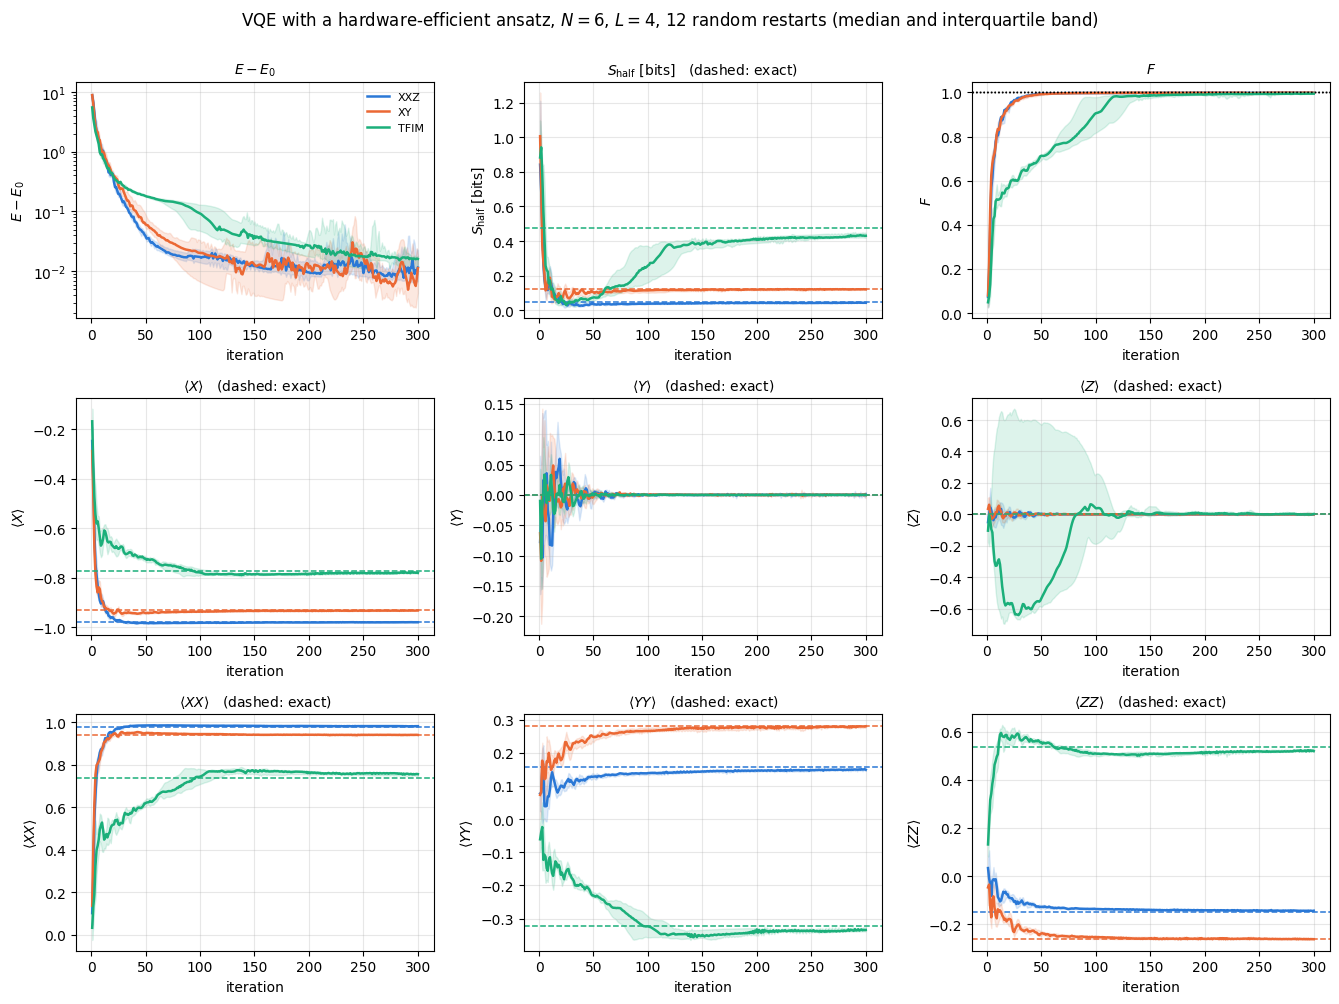

 model   observable     exact  VQE median           VQE IQR  median error
   XXZ          <X>   -0.9787     -0.9804 [-0.9808,-0.9798]       -0.0017
   XXZ          <Y>   +0.0000     +0.0008 [-0.0002,+0.0048]       +0.0008
   XXZ          <Z>   +0.0000     +0.0000 [-0.0005,+0.0021]       +0.0000
   XXZ         <XX>   +0.9798     +0.9822 [+0.9810,+0.9827]       +0.0024
   XXZ         <YY>   +0.1577     +0.1491 [+0.1453,+0.1513]       -0.0086
   XXZ         <ZZ>   -0.1468     -0.1434 [-0.1449,-0.1415]       +0.0034
    XY          <X>   -0.9324     -0.9328 [-0.9341,-0.9323]       -0.0004
    XY          <Y>   +0.0000     -0.0001 [-0.0054,+0.0003]       -0.0001
    XY          <Z>   +0.0000     -0.0005 [-0.0033,+0.0002]       -0.0005
    XY         <XX>   +0.9403     +0.9409 [+0.9401,+0.9415]       +0.0006
    XY         <YY>   +0.2822     +0.2801 [+0.2769,+0.2811]       -0.0022
    XY         <ZZ>   -0.2607     -0.2616 [-0.2631,-0.2598]       -0.0010
  TFIM          <X>   -0.7711     -0.7

In [11]:
# ==============================================================================
# STEP 8: the 3 x 3 panel of metrics -- median and interquartile band, per model
# ==============================================================================
fig, axes = plt.subplots(3, 3, figsize=(13.5, 10.0))
it_axis = np.arange(1, T_MAIN + 1)
for m, ax in enumerate(axes.ravel()):
    for i, name in enumerate(MODEL_NAMES):
        lo, med, hi = bands(HIST[i, :, :, m])
        if m == 0:
            lo, med, hi = (np.maximum(a, 1e-12) for a in (lo, med, hi))
        ax.fill_between(it_axis, lo, hi, color=PALETTE[i], alpha=0.15)
        ax.plot(it_axis, med, "-", lw=1.8, color=PALETTE[i], label=name)
        if m == 0:
            ax.set_yscale("log")
        elif m == 2:
            ax.axhline(1.0, color="k", ls=":", lw=1)
        else:
            ref = EXACT[name]["obs"][m - 2] if m >= 3 else EXACT[name]["obs"][0]
            ax.axhline(ref, color=PALETTE[i], ls="--", lw=1.1)
    ax.set_xlabel("iteration")
    ax.set_ylabel(METRIC_TEX[m])
    ax.set_title(METRIC_TEX[m] + ("" if m in (0, 2) else "   (dashed: exact)"), fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"VQE with a hardware-efficient ansatz, $N={N_SITES}$, $L={L_MAIN}$, "
             f"{R_MAIN} random restarts (median and interquartile band)", y=1.0)
fig.tight_layout(); plt.show()

print(f"{'model':>6s} {'observable':>12s} {'exact':>9s} {'VQE median':>11s} {'VQE IQR':>17s} {'median error':>13s}")
for i, name in enumerate(MODEL_NAMES):
    for m in range(3, 9):
        vals = HIST[i, :, -1, m]
        ref = EXACT[name]["obs"][m - 2]
        print(f"{name:>6s} {METRIC_KEYS[m]:>12s} {ref:+9.4f} {np.median(vals):+11.4f} "
              f"[{np.percentile(vals, 25):+.4f},{np.percentile(vals, 75):+.4f}] {np.median(vals) - ref:+13.4f}")

**The variational principle is a free unit test, and it passed.** Across $3\times12\times300=10800$ recorded
energies the error $E-E_0$ never went negative; its smallest value over the whole experiment was
$1.6\cdot10^{-3}$. Had the term list, the ansatz convention or the Lanczos reference been inconsistent, this is
where it would have shown.

**The energies converge and the states nearly do.** The median final energy error is $0.0115$ (XXZ), $0.0113$ (XY)
and $0.0161$ (TFIM), i.e. a relative error near $10^{-3}$ in every case; the median fidelities are $0.9985$,
$0.9984$ and $0.9946$. The difficulty ordering follows the gap and the entanglement of Section 4.3: $83\%$ of the
restarts reach $E-E_0<10^{-2}$ for the two nearly polarised chains, against $50\%$ for the critical Ising chain,
which also needs roughly twice as many iterations to get there (a median of $274$ against $166$ and $130$).

**The entanglement is systematically *under*-produced.** The median $S_{\mathrm{half}}$ is $0.043$ against an exact
$0.050$, $0.120$ against $0.125$, and $0.430$ against $0.473$ — below the target in all three cases, never above. A
circuit of fixed depth has a hard ceiling on the entanglement it can generate across the central cut (Section 10.1),
and the optimiser approaches that ceiling from below. This is the most robust qualitative signature of an
under-expressive variational state, and it is visible even when the energy looks converged.

**The local observables.** $\langle X\rangle$, $\langle XX\rangle$, $\langle YY\rangle$ and $\langle ZZ\rangle$ are
reproduced with errors of $10^{-3}$ to $9\cdot10^{-3}$ for the XXZ and XY chains and $10^{-2}$ to $1.7\cdot10^{-2}$
for the critical Ising chain. The comparison to keep in mind is *relative*: the Ising energy is off by $0.016$ out of $7.30$, two parts in
a thousand, while $\langle XX\rangle$ is off by $0.017$ out of $0.74$, more than two parts in a hundred. The energy
is an extensive sum of many terms whose individual errors partly cancel, and it is protected by the second-order
relation of Eq. (2); a single correlator is not. **An energy that looks converged does not certify the observables
one actually wants.**

**The symmetry shows up as a residue.** $\langle Y\rangle$ and $\langle Z\rangle$ are exactly zero in the true
ground states (Section 4.3), but the variational states return values up to $1.7\cdot10^{-3}$. That non-zero residue
is not statistical noise — these are exact expectation values of a definite state — it is the broken parity of the
ansatz, quantified in the next section.

## 9. Symmetry leakage, and an ansatz that cannot leak

### 9.1 What the hardware-efficient ansatz did with the symmetry

Section 5 established that the exact ground states are parity eigenstates with $\langle P\rangle=+1$ and that the
hardware-efficient family has no reason to respect that. Now we can ask what the optimiser did: does minimising the
energy *recover* the symmetry as a by-product? The variational principle suggests it should, because the exact
minimiser is symmetric — but only to the extent that the minimum is actually reached.

### 9.2 A problem-inspired ansatz that respects the symmetry by construction

The **Hamiltonian-variational ansatz** of
[40 — parametrized gates](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb) is built
from the Hamiltonian's own terms. For the transverse-field Ising model,

$$\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\prod_{l=L}^{1}
  \Bigl[\prod_qR_x(2h\beta_l)\Bigr]\Bigl[\prod_{\langle qq'\rangle}R_{ZZ}(2J\gamma_l)\Bigr]\,
  \vert+\rangle^{\otimes N},\qquad n_{\text{params}}=2L , \tag{13}$$

a Trotterised adiabatic path with the angles left free. It has $2L$ angles — independent of $N$ — against
$2N(L+1)$ for the hardware-efficient family.

It also **cannot break the parity of Eq. (7)**, and the proof is three lines:

* the initial state satisfies $X\vert+\rangle=\vert+\rangle$ on every qubit, so $P\vert+\rangle^{\otimes N}
  =\vert+\rangle^{\otimes N}$: it is already in the $P=+1$ sector;
* $R_x(\alpha)=e^{-i\alpha X/2}$ is a function of $X$ alone, so it commutes with $P$;
* $R_{ZZ}(\alpha)=e^{-i\alpha Z_qZ_{q'}/2}$ is a function of $Z_qZ_{q'}$, which commutes with $P$ by the two-sign-flip
  argument of Section 5.1.

Hence $P\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\vert\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle$
for *every* choice of angles, and the symmetry leakage of Eq. (8) is exactly zero. The variational search is confined
to the sector that contains the answer. We measure both claims.

HVA, 64 random parameter vectors: <P> in [1.000000000000, 1.000000000000] -> max leakage 2.66e-15

 model  median <P>  best-run <P>  median leakage  best-run leakage  exact <P>


   XXZ     +0.9988       +0.9998          0.0012          2.42e-04    +1.0000


    XY     +0.9988       +0.9998          0.0012          1.61e-04    +1.0000


  TFIM     +0.9995       +0.9993          0.0005          6.94e-04    +1.0000


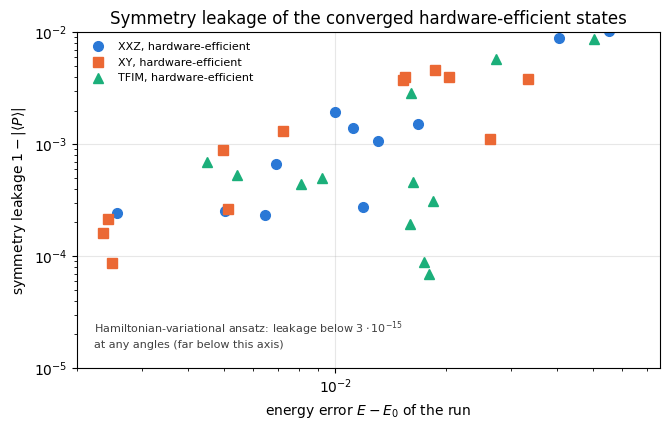

In [12]:
# ==============================================================================
# STEP 9: the Hamiltonian-variational ansatz, and the parity of every converged state
# ==============================================================================
def hva_num_params(layers):
    """Number of angles of the Hamiltonian-variational ansatz, Eq. (13): 2 per layer."""
    return 2 * layers


def hva_tfim(theta, N, layers, J=-1.0, h=1.0):
    """Hamiltonian-variational ansatz for the transverse-field Ising model, Eq. (13).

    MATH   |psi> = prod_l [ prod_q Rx(2 h beta_l) ] [ prod_bonds Rzz(2 J gamma_l) ] |+>^N
           The gates inside one factor commute, so each exponential is exact; the two factors of a layer do
           not commute with each other, which is what makes the family expressive.
    IMPL   |+>^N is Ry(pi/2) on every qubit of |0..0>:  Ry(pi/2)|0> = (|0>+|1>)/sqrt(2).
    COST   O(L N 2^N).
    """
    theta = theta.reshape(layers, 2)
    psi = zero_state(N)
    for q in range(N):
        psi = apply_gate(psi, ry(jnp.pi / 2), [q])
    for l in range(layers):
        gamma, beta = theta[l, 0], theta[l, 1]
        for q in range(N - 1):
            psi = apply_gate(psi, rzz(2.0 * J * gamma), [q, q + 1])
        for q in range(N):
            psi = apply_gate(psi, rx(2.0 * h * beta), [q])
    return psi


# --- CHECKPOINT: the HVA sits in the P = +1 sector at ANY angles -----------------------------------
th_hva_rand = jax.random.uniform(jax.random.PRNGKey(91), (64, hva_num_params(3)), minval=-jnp.pi, maxval=jnp.pi)
par_hva = np.asarray(jax.jit(jax.vmap(lambda t: parity(hva_tfim(t, N_SITES, 3))))(th_hva_rand))
print(f"HVA, 64 random parameter vectors: <P> in [{par_hva.min():.12f}, {par_hva.max():.12f}] "
      f"-> max leakage {np.max(1 - np.abs(par_hva)):.2e}")
assert np.max(1 - np.abs(par_hva)) < 1e3 * TOL

# --- parity of the hardware-efficient states that Section 8 converged to ---------------------------
print(f"\n{'model':>6s} {'median <P>':>11s} {'best-run <P>':>13s} {'median leakage':>15s} "
      f"{'best-run leakage':>17s} {'exact <P>':>10s}")
leak_tab = {}
for i, name in enumerate(MODEL_NAMES):
    pars = np.asarray(jax.jit(jax.vmap(lambda t: parity(ansatz_state(t))))(TH_FINAL[i]))
    errs = HIST[i, :, -1, 0]
    leak_tab[name] = (pars, errs)
    j = int(np.argmin(errs))
    print(f"{name:>6s} {np.median(pars):+11.4f} {pars[j]:+13.4f} {np.median(1 - np.abs(pars)):15.4f} "
          f"{1 - abs(pars[j]):17.2e} {float(parity(EXACT[name]['psi0'])):+10.4f}")

fig, ax = plt.subplots(figsize=(6.8, 4.4))
for i, name in enumerate(MODEL_NAMES):
    pars, errs = leak_tab[name]
    ax.loglog(np.maximum(errs, 1e-12), np.maximum(1 - np.abs(pars), 1e-16), MARKERS[i], ms=7,
              color=PALETTE[i], label=f"{name}, hardware-efficient")
ax.set_ylim(1e-5, 1e-2)
ax.text(0.03, 0.06, "Hamiltonian-variational ansatz: leakage below $3\\cdot10^{-15}$\nat any angles (far below this axis)",
        transform=ax.transAxes, fontsize=8, color="0.25")
ax.set_xlabel(r"energy error $E-E_0$ of the run")
ax.set_ylabel(r"symmetry leakage $1-\vert\langle P\rangle\vert$")
ax.set_title("Symmetry leakage of the converged hardware-efficient states")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

**The Hamiltonian-variational ansatz is exactly symmetric.** Over 64 random parameter vectors its parity is
$1.000000000000$ to twelve printed digits, with a largest leakage of $2.7\cdot10^{-15}$ — round-off, not physics.
The three-line proof above is confirmed: the family never leaves the $P=+1$ sector, so half of the Hilbert space is
removed from the search before the optimiser starts.

**The hardware-efficient ansatz learns the symmetry, approximately.** The converged states have a median leakage of
$1.2\cdot10^{-3}$ (XXZ and XY) and $5\cdot10^{-4}$ (TFIM), against the median of $0.94$ at random angles measured in
Section 5.3. Minimising the energy has recovered three of the sixteen available digits of a symmetry that the circuit
has no structural reason to possess — and it has recovered them only to the accuracy to which it found the minimum.
The scatter plot shows the two quantities tracking each other: the runs with the smallest energy error are also the
ones with the smallest leakage, the best TFIM run reaching $6.9\cdot10^{-4}$.

The leakage is a *diagnostic that costs nothing and needs no exact solution*: $\langle P\rangle$ is the expectation
value of one Pauli string, measurable on hardware in a single setting. A converged VQE run whose state has
$\lvert\langle P\rangle\rvert$ far from $1$ is announcing that it has not converged, without any reference state
being available.

> **Common pitfall.** "The ansatz respects the symmetry" is a claim about the *circuit*, not about the trained state.
> The right check is the one above: evaluate the symmetry generator at random angles. If it is not conserved there,
> it is not conserved — no matter how symmetric the converged state happens to look.

## 10. Depth: expressivity, entanglement and trainability

### 10.1 Entanglement capacity of a depth-$L$ circuit

Cut the chain in the middle, between qubits $N/2-1$ and $N/2$. Every gate of the hardware-efficient ansatz is either a
single-qubit rotation — which cannot change the Schmidt spectrum across a cut it does not straddle — or a $CZ$ acting
on a nearest-neighbour pair. Exactly **one** pair per entangling layer straddles the central cut. A two-qubit gate can
increase the entanglement entropy across a cut by at most $\log_2$ of the dimension it acts on per side, i.e. by at
most one bit. With $L$ entangling layers,

$$S_{\mathrm{half}}\bigl(\vert\psi(\boldsymbol\theta)\rangle\bigr)\;\le\;L\ \text{bits}. \tag{9}$$

This is a hard constraint on the family, independent of any optimiser. If the target ground state has
$S_{\mathrm{half}}>L$, no choice of angles can reach it. Equation (9) is the elementary version of the
entanglement-area-law argument that also underlies matrix-product states
([18 — MPS and TEBD](../ch07_tensor_networks/18_mps_tebd.ipynb)), where the bond dimension $\chi$ plays the role of
$2^L$.

### 10.2 Counting parameters

The second constraint is dimensional. A general $N$-qubit pure state has $2\cdot2^N-2$ real parameters (complex
amplitudes minus normalisation and global phase); for $N=6$ that is $126$, while the ansatz has $n=2N(L+1)=12(L+1)$,
so $n\ge126$ requires $L\ge10$. Notebook 41 measured that the success rate for a **Haar-random** target rises sharply
exactly when $n$ crosses $2\cdot2^N-2$ — the overparametrisation threshold. A ground state is not a random state: it
is a low-entanglement, symmetric, structured state, so the relevant count should be far smaller. Which of the two
constraints binds here is a measurement, not a guess.

depth scan: 5 depths x 3 models x 8 restarts x 250 iterations in 36.1 s

  L    n  bound S<=L |             XXZ dE/F/S |              XY dE/F/S |            TFIM dE/F/S
  1   24           1 |  0.0379  0.995  0.0228 |  0.1373  0.983  0.0363 |  0.2131  0.642  0.0127
  2   36           2 |  0.0145  0.998  0.0384 |  0.0274  0.997  0.1028 |  0.1252  0.857  0.1872
  3   48           3 |  0.0115  0.999  0.0426 |  0.0201  0.998  0.1148 |  0.0355  0.987  0.3893
  4   60           4 |  0.0102  0.999  0.0432 |  0.0136  0.998  0.1219 |  0.0124  0.997  0.4438
  6   84           6 |  0.0123  0.998  0.0436 |  0.0099  0.999  0.1226 |  0.0094  0.997  0.4521

exact half-chain entropies: XXZ 0.0498, XY 0.1248, TFIM 0.4732


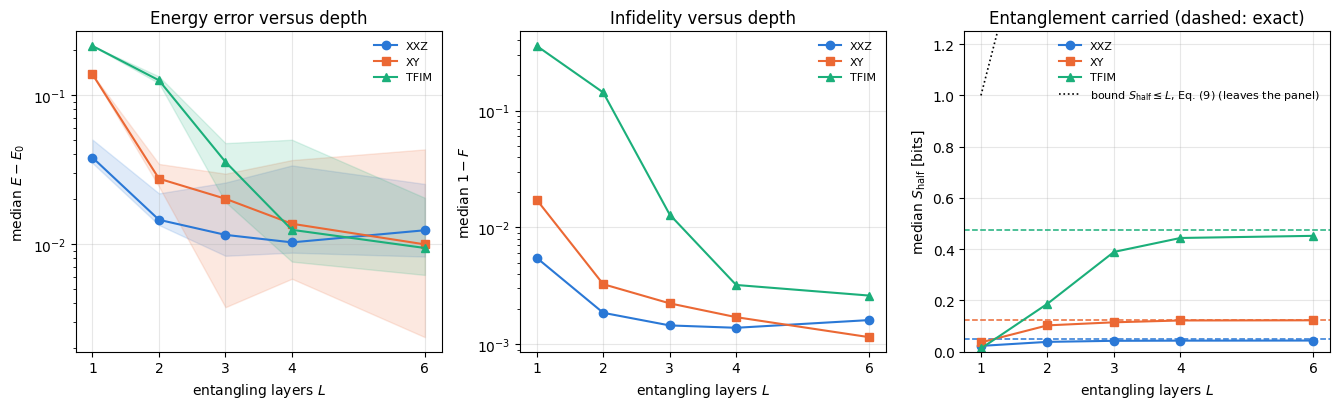

In [13]:
# ==============================================================================
# STEP 10: energy error, fidelity and entanglement versus the number of layers
# ==============================================================================
DEPTHS = (1, 2, 3, 4, 6)
R_DEPTH, T_DEPTH, R_DEPTH_HVA = 8, 250, 12
depth_rows = []
t0 = time.perf_counter()
for L in DEPTHS:
    n_L = hea_num_params(N_SITES, L)
    th_L, ks_L = random_starts(R_DEPTH, n_L, seed=41 + L)
    run_L = jax.jit(jax.vmap(lambda c, p, e: vqe_run(c, p, e, th_L, ks_L, LR_BEST, T_DEPTH, layers=L)[1]))
    h = np.asarray(jax.block_until_ready(run_L(C_STACK, PSI_STACK, E0_STACK)))     # (3, runs, steps, 9)
    depth_rows.append(h)
print(f"depth scan: {len(DEPTHS)} depths x 3 models x {R_DEPTH} restarts x {T_DEPTH} iterations "
      f"in {time.perf_counter() - t0:.1f} s")

print(f"\n{'L':>3s} {'n':>4s} {'bound S<=L':>11s} | " +
      " | ".join(f"{k + ' dE/F/S':>22s}" for k in MODEL_NAMES))
for j, L in enumerate(DEPTHS):
    cells = []
    for i, name in enumerate(MODEL_NAMES):
        h = depth_rows[j][i]
        cells.append(f"{np.median(h[:, -1, 0]):7.4f} {np.median(h[:, -1, 2]):6.3f} {np.median(h[:, -1, 1]):7.4f}")
    print(f"{L:3d} {hea_num_params(N_SITES, L):4d} {L:11d} | " + " | ".join(f"{c:>22s}" for c in cells))
print("\nexact half-chain entropies: " +
      ", ".join(f"{k} {EXACT[k]['obs'][0]:.4f}" for k in MODEL_NAMES))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
ns = [hea_num_params(N_SITES, L) for L in DEPTHS]
for i, name in enumerate(MODEL_NAMES):
    med_dE = [np.median(depth_rows[j][i][:, -1, 0]) for j in range(len(DEPTHS))]
    lo_dE = [np.percentile(depth_rows[j][i][:, -1, 0], 25) for j in range(len(DEPTHS))]
    hi_dE = [np.percentile(depth_rows[j][i][:, -1, 0], 75) for j in range(len(DEPTHS))]
    med_F = [np.median(depth_rows[j][i][:, -1, 2]) for j in range(len(DEPTHS))]
    med_S = [np.median(depth_rows[j][i][:, -1, 1]) for j in range(len(DEPTHS))]
    axes[0].semilogy(DEPTHS, med_dE, MARKERS[i] + "-", ms=6, color=PALETTE[i], label=name)
    axes[0].fill_between(DEPTHS, lo_dE, hi_dE, color=PALETTE[i], alpha=0.15)
    axes[1].semilogy(DEPTHS, np.maximum(1 - np.array(med_F), 1e-6), MARKERS[i] + "-", ms=6, color=PALETTE[i], label=name)
    axes[2].plot(DEPTHS, med_S, MARKERS[i] + "-", ms=6, color=PALETTE[i], label=name)
    axes[2].axhline(EXACT[name]["obs"][0], color=PALETTE[i], ls="--", lw=1.1)
axes[2].plot(DEPTHS, DEPTHS, "k:", lw=1.2, label=r"bound $S_{\rm half}\leq L$, Eq. (9) (leaves the panel)")
axes[2].set_ylim(0, 1.25)
axes[0].set_xlabel("entangling layers $L$"); axes[0].set_ylabel(r"median $E-E_0$")
axes[0].set_title("Energy error versus depth"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("entangling layers $L$"); axes[1].set_ylabel(r"median $1-F$")
axes[1].set_title("Infidelity versus depth"); axes[1].legend(fontsize=8)
axes[2].set_xlabel("entangling layers $L$"); axes[2].set_ylabel(r"median $S_{\rm half}$ [bits]")
axes[2].set_title("Entanglement carried (dashed: exact)"); axes[2].legend(fontsize=8)
for a in axes:
    a.set_xticks(DEPTHS)
fig.tight_layout(); plt.show()

**Depth buys accuracy where accuracy is missing, and nothing where it is not.** For the critical Ising chain the
median energy error falls monotonically from $0.213$ at $L=1$ through $0.125$, $0.036$, $0.0124$ to $0.0094$ at
$L=6$, and the median fidelity rises from $0.64$ to $0.997$. For the two nearly polarised chains the curve flattens
after $L=2$: XXZ goes $0.038\to0.0145\to0.0115\to0.0102$ and then *up* again to $0.0123$ at $L=6$. Adding
parameters to a family that already contains a good enough state does not help, and can hurt by making the
landscape harder to search with a fixed iteration budget.

**The entanglement bound of Eq. (9) is not what limits the accuracy here.** The bound allows $L$ bits; the targets
need $0.05$, $0.12$ and $0.47$ bits, so even $L=1$ has enough capacity for all three. Yet at $L=1$ the optimised
Ising state carries only $0.013$ bits and misses the energy by $0.21$. The entanglement produced climbs with depth —
$0.013$, $0.187$, $0.389$, $0.444$, $0.452$ bits against the exact $0.473$ — approaching the target from below,
exactly as in Section 8, but always far below the $L$-bit ceiling. **Equation (9) is a necessary condition, not a
sufficient one**: what limits a shallow hardware-efficient circuit is the shape of the reachable set, not its
entanglement capacity.

**The parameter count tells the same story.** All the depths here have $n=24$ to $84$ angles, and a general
six-qubit state needs $2\cdot2^N-2=126$: the overparametrisation threshold that notebook 41 located so sharply for a
**Haar-random** target is never crossed, and yet the median fidelity reaches $0.997$. The reason is that a ground
state is not a random state. It is low-entanglement, symmetric and structured, and it lives in a tiny corner of the
Hilbert space that a circuit with far fewer than $2\cdot2^N-2$ parameters can reach. The counting threshold is the
right criterion for the worst case and a pessimistic one for physics.

### 10.3 The same study with the Hamiltonian-variational ansatz

The hardware-efficient family buys its expressivity with parameters: $12(L+1)$ of them at $N=6$. The
Hamiltonian-variational ansatz of Eq. (13) has $2L$ — at $L=6$ that is twelve angles against eighty-four. If a
problem-inspired structure is worth anything, it should show here: the same critical Ising ground state, the same
optimiser, a small fraction of the parameters.

The two families live on landscapes with different curvature scales, so re-using the step size tuned in Section 7
would be exactly the mistake that notebook 41 warned against. Each depth therefore gets its own sweep over four step
sizes — a nested `vmap`, one compilation per depth — and we report the best of the four. We also report the **best**
run next to the median, because the two turn out to differ by orders of magnitude for one of the families.

HVA depth scan (4 step sizes per depth) in 27.8 s

critical Ising chain, N=6: two ansatz families
  L |  HEA n  median E-E_0      best  median F |  HVA n  best lr  median E-E_0      best  median F
  1 |     24       0.21307   0.21304    0.6420 |      -        -             -         -         -
  2 |     36       0.12523   0.11679    0.8571 |      4     0.10       4.06599   4.00817    0.1827
  3 |     48       0.03550   0.00802    0.9871 |      -        -             -         -         -
  4 |     60       0.01242   0.00551    0.9968 |      8     0.05       2.15041   1.96829    0.4136
  6 |     84       0.00938   0.00511    0.9974 |     12     0.10       0.91832   0.02827    0.7160
  8 |      -             -         -         - |     16     0.40       0.07494   0.00706    0.9839


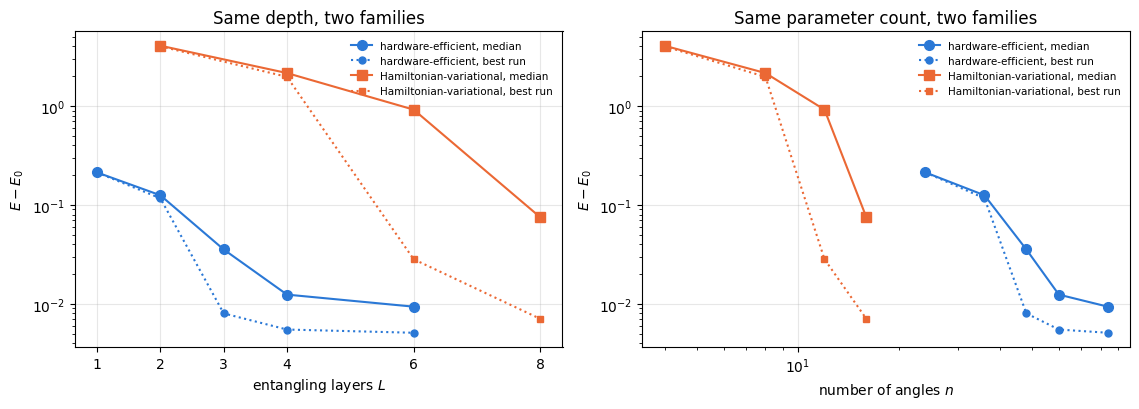

In [14]:
# ==============================================================================
# STEP 11: HVA depth scan on the critical Ising chain, each depth at its own best step size
# ==============================================================================
HVA_DEPTHS = (2, 4, 6, 8)
LR_GRID_HVA = jnp.asarray([0.05, 0.1, 0.2, 0.4], dtype=RDTYPE)
hva_rows, hva_lr = [], []
t0 = time.perf_counter()
for L in HVA_DEPTHS:
    nL = hva_num_params(L)
    th_L, ks_L = random_starts(R_DEPTH_HVA, nL, seed=71 + L)

    def cost_hva(t, L=L):
        return energy(model_terms(N_SITES, c_tfim), hva_tfim(t, N_SITES, L))

    def mon_hva(t, L=L):
        psi = hva_tfim(t, N_SITES, L)
        return jnp.stack([energy(model_terms(N_SITES, c_tfim), psi) - E0_tfim,
                          entanglement_entropy(psi, range(N_SITES // 2)),
                          fidelity_pure(psi0_tfim, psi)])

    # nested vmap: one compilation for the whole (step size x restart) grid at this depth
    h = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(lambda lr: jax.vmap(lambda t, k: train(
        t, k, grad_exact(cost_hva), opt_adam(lr), mon_hva, T_DEPTH)[1])(th_L, ks_L)))(LR_GRID_HVA)))
    j_best = int(np.argmin(np.median(h[:, :, -1, 0], axis=1)))
    hva_rows.append(h[j_best]); hva_lr.append(float(np.asarray(LR_GRID_HVA)[j_best]))
print(f"HVA depth scan ({len(LR_GRID_HVA)} step sizes per depth) in {time.perf_counter() - t0:.1f} s")

i_tfim = MODEL_NAMES.index("TFIM")
print(f"\ncritical Ising chain, N={N_SITES}: two ansatz families")
print(f"{'L':>3s} | {'HEA n':>6s} {'median E-E_0':>13s} {'best':>9s} {'median F':>9s} | "
      f"{'HVA n':>6s} {'best lr':>8s} {'median E-E_0':>13s} {'best':>9s} {'median F':>9s}")
for L in sorted(set(DEPTHS) | set(HVA_DEPTHS)):
    hea_cell = "     -             -         -         -"
    if L in DEPTHS:
        hh = depth_rows[DEPTHS.index(L)][i_tfim]
        hea_cell = (f"{hea_num_params(N_SITES, L):6d} {np.median(hh[:, -1, 0]):13.5f} {hh[:, -1, 0].min():9.5f} "
                    f"{np.median(hh[:, -1, 2]):9.4f}")
    hva_cell = "     -        -             -         -         -"
    if L in HVA_DEPTHS:
        hv = hva_rows[HVA_DEPTHS.index(L)]
        hva_cell = (f"{hva_num_params(L):6d} {hva_lr[HVA_DEPTHS.index(L)]:8.2f} {np.median(hv[:, -1, 0]):13.5f} "
                    f"{hv[:, -1, 0].min():9.5f} {np.median(hv[:, -1, 2]):9.4f}")
    print(f"{L:3d} | {hea_cell} | {hva_cell}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
med_hea = [np.median(depth_rows[j][i_tfim][:, -1, 0]) for j in range(len(DEPTHS))]
med_hva = [np.median(hva_rows[j][:, -1, 0]) for j in range(len(HVA_DEPTHS))]
best_hea = [depth_rows[j][i_tfim][:, -1, 0].min() for j in range(len(DEPTHS))]
best_hva = [hva_rows[j][:, -1, 0].min() for j in range(len(HVA_DEPTHS))]
axes[0].semilogy(DEPTHS, med_hea, MARKERS[0] + "-", ms=7, color=PALETTE[0], label="hardware-efficient, median")
axes[0].semilogy(DEPTHS, best_hea, MARKERS[0] + ":", ms=5, color=PALETTE[0], label="hardware-efficient, best run")
axes[0].semilogy(HVA_DEPTHS, med_hva, MARKERS[1] + "-", ms=7, color=PALETTE[1], label="Hamiltonian-variational, median")
axes[0].semilogy(HVA_DEPTHS, best_hva, MARKERS[1] + ":", ms=5, color=PALETTE[1],
                 label="Hamiltonian-variational, best run")
axes[0].set_xlabel("entangling layers $L$"); axes[0].set_ylabel(r"$E-E_0$")
axes[0].set_xticks(sorted(set(DEPTHS) | set(HVA_DEPTHS)))
axes[0].set_title("Same depth, two families"); axes[0].legend(fontsize=7.5)

axes[1].loglog([hea_num_params(N_SITES, L) for L in DEPTHS], med_hea, MARKERS[0] + "-", ms=7,
               color=PALETTE[0], label="hardware-efficient, median")
axes[1].loglog([hea_num_params(N_SITES, L) for L in DEPTHS], best_hea, MARKERS[0] + ":", ms=5,
               color=PALETTE[0], label="hardware-efficient, best run")
axes[1].loglog([hva_num_params(L) for L in HVA_DEPTHS], med_hva, MARKERS[1] + "-", ms=7,
               color=PALETTE[1], label="Hamiltonian-variational, median")
axes[1].loglog([hva_num_params(L) for L in HVA_DEPTHS], best_hva, MARKERS[1] + ":", ms=5,
               color=PALETTE[1], label="Hamiltonian-variational, best run")
axes[1].set_xlabel("number of angles $n$"); axes[1].set_ylabel(r"$E-E_0$")
axes[1].set_title("Same parameter count, two families"); axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

The two families answer two different questions, and the two panels separate them.

**At equal depth the hardware-efficient ansatz wins, comfortably.** At $L=6$ its median error is $0.0094$ against
$0.918$ for the Hamiltonian-variational circuit. That is not surprising: at $L=6$ the one family has $84$ free
angles and the other has $12$.

**At equal parameter count the ranking reverses.** With $16$ angles ($L=8$) the Hamiltonian-variational ansatz
reaches a median error of $0.075$, a best run of $0.0071$ and a median fidelity of $0.984$; the hardware-efficient
circuit with the comparable $24$ angles ($L=1$) manages a median of $0.213$ and a fidelity of $0.642$ — a factor of
three worse in the median, and thirty times worse when the best runs are compared ($0.213$ against $0.0071$). Twelve
problem-inspired angles at $L=6$ already produce a best run of $0.028$. The structure taken from the Hamiltonian is
worth a large factor in parameters, which on hardware is a large factor in parameter-shift circuits per iteration.

**The Hamiltonian-variational landscape is far rougher.** Look at the gap between the median and the best run: at
$L=6$ it is $0.918$ against $0.028$, a factor of thirty across twelve restarts of the *same* configuration, whereas
the hardware-efficient family at $L=6$ gives $0.0094$ against $0.0051$, a factor of two. The problem-inspired
circuit contains excellent solutions and a landscape full of local minima that hides them; the hardware-efficient
circuit is easy to optimise and its optimum is mediocre at small $n$. This is the trade-off that governs ansatz
design, and it is the reason that any claim about a variational ansatz must be reported as a distribution over
restarts rather than as a best run.

> **Numerical practice.** The step sizes were re-tuned per depth and per family (the chosen values are printed in
> the table, and they differ by a factor of eight across the scan). Carrying over the $\eta=0.4$ of Section 7 would
> have made the Hamiltonian-variational family look much worse than it is — and would have been a statement about
> the step size, not about the ansatz.

## 11. Across the phase diagram of the transverse-field Ising chain

### 11.1 The physics

Take the TFIM of Eq. (6), $H=-\sum_qZ_qZ_{q+1}+h\sum_qX_q$, and vary $h$. The two limits are elementary:

* $h=0$: the Hamiltonian is diagonal in the $Z$ basis and the two ground states are
  $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$ — **ferromagnetic order**, twofold degenerate;
* $h\to\infty$: the field wins, and the unique ground state is the product state
  $\vert-\rangle^{\otimes N}$ with $\langle X_q\rangle=-1$ — the **paramagnetic** phase.

In the thermodynamic limit these are separated by a quantum critical point at $\lvert h\rvert=1$, where the gap
closes as $1/N$ and the half-chain entanglement grows logarithmically with $N$. On a finite open chain there is no
true degeneracy: tunnelling between the two ordered configurations splits the doublet by an amount that vanishes
**exponentially** in $N$, and the two lowest eigenvectors are the symmetric and antisymmetric combinations

$$\vert\pm\rangle\simeq\frac{\vert{\uparrow\cdots\uparrow}\rangle\pm\vert{\downarrow\cdots\downarrow}\rangle}{\sqrt2},
  \qquad P\vert\pm\rangle=\pm\vert\pm\rangle ,$$

i.e. cat states with exactly one bit of half-chain entanglement.

### 11.2 What that does to the fidelity

Here is the trap. Deep in the ordered phase the exact ground state returned by Lanczos is the cat state $\vert+\rangle$.
A variational state that has collapsed onto **one** of the two ordered configurations has an energy that is higher by
half the (exponentially small) splitting — utterly invisible to the optimiser — but its fidelity with $\vert+\rangle$
is

$$F=\bigl\lvert\langle+\vert{\uparrow\cdots\uparrow}\rangle\bigr\rvert^{2}=\tfrac12 . \tag{10}$$

So we should expect, and will measure, a region of the phase diagram where the energy error is essentially zero while
the fidelity sits at $1/2$. That is not a failure of the optimiser and it is not a bug; it is the statement that
fidelity with a particular member of a degenerate eigenspace is a meaningless figure of merit. The physically
meaningful questions there are about *observables* — the order parameter, the correlators — and about the fidelity
with the whole degenerate subspace, $F_{\text{sub}}=\lvert\langle+\vert\psi\rangle\rvert^2+\lvert\langle-\vert\psi\rangle\rvert^2$,
which we also measure.

The field sweep is one compiled program: the coefficient vector $\mathbf c(h)=(0,0,-1,h)$ is traced, and `vmap` runs
over its values.

In [15]:
# ==============================================================================
# STEP 12: exact references across the field sweep
# ==============================================================================
H_GRID = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0])
ref_h = {"E0": [], "E1": [], "gap": [], "S": [], "psi0": [], "psi1": []}
for h in H_GRID:
    terms_h = model_terms(N_SITES, jnp.asarray((0.0, 0.0, -1.0, float(h)), dtype=RDTYPE))
    w, V = np.linalg.eigh(np.asarray(dense_hamiltonian(terms_h, N_SITES)))
    p0 = jnp.asarray(V[:, 0], dtype=CDTYPE).reshape((2,) * N_SITES)
    p1 = jnp.asarray(V[:, 1], dtype=CDTYPE).reshape((2,) * N_SITES)
    ref_h["E0"].append(float(w[0])); ref_h["E1"].append(float(w[1]))
    ref_h["gap"].append(float(w[1] - w[0])); ref_h["S"].append(float(entanglement_entropy(p0, range(N_SITES // 2))))
    ref_h["psi0"].append(p0); ref_h["psi1"].append(p1)
print(f"{'h':>5s} {'E_0':>10s} {'E_1 - E_0':>12s} {'S_half':>8s} {'parity of |0>':>14s} {'parity of |1>':>14s}")
for j, h in enumerate(H_GRID):
    print(f"{h:5.2f} {ref_h['E0'][j]:10.5f} {ref_h['gap'][j]:12.3e} {ref_h['S'][j]:8.4f} "
          f"{float(parity(ref_h['psi0'][j])):+14.3f} {float(parity(ref_h['psi1'][j])):+14.3f}")

    h        E_0    E_1 - E_0   S_half  parity of |0>  parity of |1>
 0.20   -5.08031    1.229e-04   0.9999         +1.000         -1.000
 0.40   -5.32762    6.882e-03   0.9903         +1.000         -1.000
 0.60   -5.77092    6.018e-02   0.9031         +1.000         -1.000
 0.80   -6.43971    2.194e-01   0.6868         +1.000         -1.000
 1.00   -7.29623    4.821e-01   0.4732         +1.000         -1.000
 1.20   -8.26934    8.055e-01   0.3334         +1.000         -1.000
 1.50   -9.84757    1.343e+00   0.2171         +1.000         -1.000
 2.00  -12.63096    2.293e+00   0.1278         +1.000         -1.000


field sweep: 8 fields x 8 restarts x 250 iterations in 8.0 s

    h        gap  S_exact  median E-E_0   best E-E_0  median F median F_sub median S_vqe  median <P>  1-F bound
 0.20  1.229e-04   0.9999       0.00020      0.00007    0.5000       0.9999       0.0001     +0.0000      1.000
 0.40  6.882e-03   0.9903       0.00377      0.00359    0.5018       0.9999       0.0015     +0.0037      0.548
 0.60  6.018e-02   0.9031       0.02999      0.02951    0.5222       0.9996       0.0112     +0.0449      0.498
 0.80  2.194e-01   0.6868       0.06367      0.00854    0.8477       0.9881       0.3515     +0.7165      0.290
 1.00  4.821e-01   0.4732       0.01873      0.00251    0.9939       0.9939       0.4200     +0.9994      0.039
 1.20  8.055e-01   0.3334       0.00894      0.00597    0.9975       0.9975       0.3130     +0.9992      0.011
 1.50  1.343e+00   0.2171       0.01607      0.00557    0.9967       0.9968       0.2064     +0.9969      0.012
 2.00  2.293e+00   0.1278       0.01202   

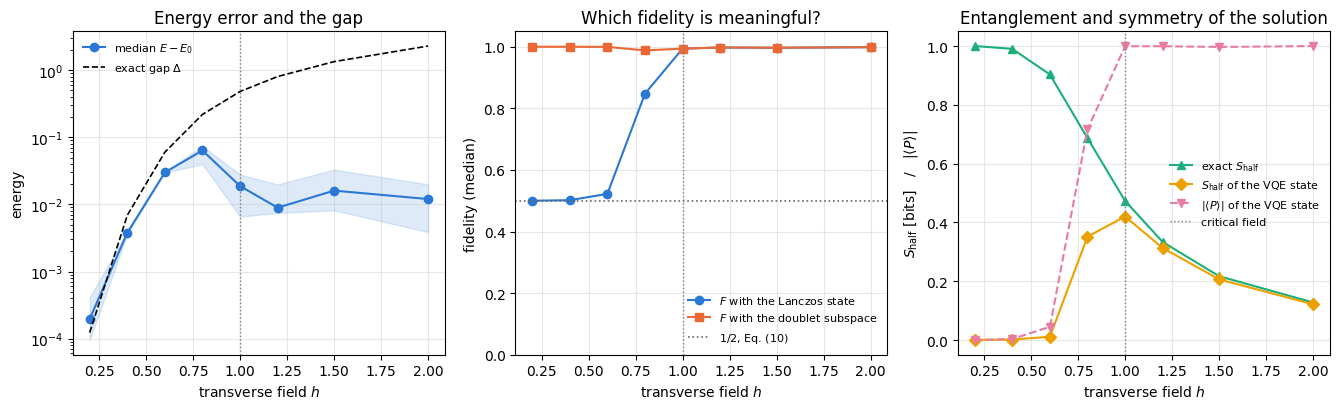

In [16]:
# ==============================================================================
# STEP 13: VQE across the sweep -- one compilation, vmapped over the field
# ==============================================================================
R_SWEEP, T_SWEEP, L_SWEEP = 8, 250, 4
n_sweep = hea_num_params(N_SITES, L_SWEEP)
th_sw, ks_sw = random_starts(R_SWEEP, n_sweep, seed=51)
C_H = jnp.stack([jnp.asarray((0.0, 0.0, -1.0, float(h)), dtype=RDTYPE) for h in H_GRID])
PSI0_H = jnp.stack(ref_h["psi0"])
PSI1_H = jnp.stack(ref_h["psi1"])
E0_H = jnp.asarray(ref_h["E0"], dtype=RDTYPE)


def sweep_one(c, p0, p1, e0):
    """Train R_SWEEP restarts at one field.

    Monitor: (E - E_0, fidelity with the Lanczos state, fidelity with the doublet subspace,
              half-chain entropy, parity) -- five numbers per iteration per restart.
    """
    cost = lambda t: vqe_cost(t, c, layers=L_SWEEP)

    def monitor(t):
        psi = ansatz_state(t, layers=L_SWEEP)
        f0, f1 = fidelity_pure(p0, psi), fidelity_pure(p1, psi)
        return jnp.stack([energy(model_terms(N_SITES, c), psi) - e0, f0, f0 + f1,
                          entanglement_entropy(psi, range(N_SITES // 2)), parity(psi)])

    return jax.vmap(lambda t, k: train(t, k, grad_exact(cost), opt_adam(LR_BEST), monitor, T_SWEEP)[1])(th_sw, ks_sw)


t0 = time.perf_counter()
H_SW = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(sweep_one))(C_H, PSI0_H, PSI1_H, E0_H)))
print(f"field sweep: {len(H_GRID)} fields x {R_SWEEP} restarts x {T_SWEEP} iterations "
      f"in {time.perf_counter() - t0:.1f} s")

print(f"\n{'h':>5s} {'gap':>10s} {'S_exact':>8s} {'median E-E_0':>13s} {'best E-E_0':>12s} "
      f"{'median F':>9s} {'median F_sub':>12s} {'median S_vqe':>12s} {'median <P>':>11s} {'1-F bound':>10s}")
for j, h in enumerate(H_GRID):
    med_dE = np.median(H_SW[j, :, -1, 0])
    print(f"{h:5.2f} {ref_h['gap'][j]:10.3e} {ref_h['S'][j]:8.4f} {med_dE:13.5f} {H_SW[j, :, -1, 0].min():12.5f} "
          f"{np.median(H_SW[j, :, -1, 1]):9.4f} {np.median(H_SW[j, :, -1, 2]):12.4f} "
          f"{np.median(H_SW[j, :, -1, 3]):12.4f} {np.median(H_SW[j, :, -1, 4]):+11.4f} "
          f"{min(1.0, med_dE / ref_h['gap'][j]):10.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
axes[0].semilogy(H_GRID, [np.median(H_SW[j, :, -1, 0]) for j in range(len(H_GRID))], MARKERS[0] + "-",
                 ms=6, color=PALETTE[0], label=r"median $E-E_0$")
axes[0].fill_between(H_GRID, [np.percentile(H_SW[j, :, -1, 0], 25) for j in range(len(H_GRID))],
                     [np.percentile(H_SW[j, :, -1, 0], 75) for j in range(len(H_GRID))],
                     color=PALETTE[0], alpha=0.15)
axes[0].semilogy(H_GRID, ref_h["gap"], "k--", lw=1.2, label=r"exact gap $\Delta$")
axes[0].axvline(1.0, color="0.5", lw=1, ls=":")
axes[0].set_xlabel("transverse field $h$"); axes[0].set_ylabel("energy")
axes[0].set_title("Energy error and the gap"); axes[0].legend(fontsize=8)

axes[1].plot(H_GRID, [np.median(H_SW[j, :, -1, 1]) for j in range(len(H_GRID))], MARKERS[0] + "-",
             ms=6, color=PALETTE[0], label=r"$F$ with the Lanczos state")
axes[1].plot(H_GRID, [np.median(H_SW[j, :, -1, 2]) for j in range(len(H_GRID))], MARKERS[1] + "-",
             ms=6, color=PALETTE[1], label=r"$F$ with the doublet subspace")
axes[1].axhline(0.5, color="0.4", ls=":", lw=1.2, label=r"$1/2$, Eq. (10)")
axes[1].axvline(1.0, color="0.5", lw=1, ls=":")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("transverse field $h$"); axes[1].set_ylabel("fidelity (median)")
axes[1].set_title("Which fidelity is meaningful?"); axes[1].legend(fontsize=8)

axes[2].plot(H_GRID, ref_h["S"], MARKERS[2] + "-", ms=6, color=PALETTE[2], label=r"exact $S_{\rm half}$")
axes[2].plot(H_GRID, [np.median(H_SW[j, :, -1, 3]) for j in range(len(H_GRID))], MARKERS[3] + "-", ms=6,
             color=PALETTE[3], label=r"$S_{\rm half}$ of the VQE state")
axes[2].plot(H_GRID, [np.median(np.abs(H_SW[j, :, -1, 4])) for j in range(len(H_GRID))], MARKERS[4] + "--", ms=6,
             color=PALETTE[4], label=r"$\vert\langle P\rangle\vert$ of the VQE state")
axes[2].axvline(1.0, color="0.5", lw=1, ls=":", label="critical field")
axes[2].set_xlabel("transverse field $h$"); axes[2].set_ylabel(r"$S_{\rm half}$ [bits]   /   $\vert\langle P\rangle\vert$")
axes[2].set_title("Entanglement and symmetry of the solution"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 11.3 Reading the sweep

**Equation (10) is confirmed to four digits.** At $h=0.2$ the median fidelity with the Lanczos ground state is
$0.5000$ while the fidelity with the two-dimensional doublet subspace is $0.9999$ — and the median energy error is
$2.0\cdot10^{-4}$. The variational state is an essentially perfect member of the ground doublet that happens to be
orthogonal to the other member. Quoting $F=0.5$ as a failure would be a misreading; quoting $F_{\text{sub}}=0.9999$
is the honest statement.

**The extra columns identify what the optimiser found.** At $h\le0.6$ the half-chain entropy of the variational
state is $0.0001$, $0.0015$, $0.011$ bits while the exact ground state has $1.00$, $0.99$, $0.90$ bits, and the
variational parity is $0.000$, $0.004$, $0.045$ against the exact $+1$. The optimiser found a **symmetry-broken,
essentially unentangled** state — one of the two ferromagnetic configurations — rather than their cat-like
superposition. That is the energetically sensible thing to do: the two differ in energy by the tunnelling splitting,
$1.2\cdot10^{-4}$ at $h=0.2$, which is below anything the optimiser could resolve, and the broken state is vastly
easier for a shallow circuit to prepare. Between $h=0.6$ and $h=1.0$ the parity climbs $0.045\to0.72\to0.9994$ and
the entropy $0.011\to0.35\to0.42$: the symmetry is restored exactly where the splitting becomes resolvable.

**The hardest field is $h=0.8$, not the critical point.** The median energy error peaks there at $0.064$, against
$0.019$ at $h=1$ and $0.0004$ at $h=0.2$, and the spread across restarts is largest there too (best run $0.0085$).
That is the crossover region: the doublet splitting, $0.22$, is now large enough that the cheap symmetry-broken
solution is no longer good enough, but the true ground state still carries $0.69$ bits of entanglement — more than
at criticality. The circuit is asked for the most and offered the least guidance.

**A correction to a common expectation.** "Entanglement peaks at the critical point" is a statement about scaling
with $N$, not about the value at a given $N$. Here the exact half-chain entropy *decreases* monotonically with $h$,
from $1.00$ bit deep in the ordered phase to $0.13$ at $h=2$, and the critical value $0.47$ is in between. The
ordered phase of a finite open chain has a cat-state ground state whose entanglement is exactly one bit
**independently of $N$**, while the critical entropy grows like $\tfrac16\log_2N$ and overtakes it only for chains
far longer than six sites. What distinguishes the critical point at $N=6$ is not the amount of entanglement but the
gap, which is the smallest of the resolvable ones and closes as $1/N$.

**The certificate of Eq. (5) degrades exactly as predicted.** The last column is $(E-E_0)/\Delta$, the bound on the
infidelity that a practitioner could quote without knowing the exact state. At $h=2$ it reads $0.005$ against a true
infidelity of $0.0015$ — useful. At $h=0.2$ it reads $1.000$, i.e. nothing at all, because the gap is
$1.2\cdot10^{-4}$. Where the gap closes, the energy stops saying anything about the state.

## 12. An excited state: variational quantum deflation

VQE minimises. To get the *first excited* state one changes the cost so that its minimum is the first excited state.
**Variational quantum deflation** (Higgott, Wang and Brierley, 2019) adds an orthogonality penalty: having found an
approximation $\vert\psi_\star\rangle$ to the ground state, minimise

$$C_1(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle
  +\beta\,\bigl\lvert\langle\psi_\star\vert\psi(\boldsymbol\theta)\rangle\bigr\rvert^{2} . \tag{11}$$

### 12.1 The required size of $\beta$

Suppose $\vert\psi_\star\rangle=\vert\psi_0\rangle$ exactly, and write the trial state in the eigenbasis as in
Eq. (1). Then

$$C_1=\sum_n\lvert c_n\rvert^2E_n+\beta\lvert c_0\rvert^2=\lvert c_0\rvert^2(E_0+\beta)+\sum_{n\ge1}\lvert c_n\rvert^2E_n .$$

This is again a weighted average, now of the *shifted* spectrum $\{E_0+\beta,E_1,E_2,\dots\}$, so by exactly the
argument of Eq. (1) its minimum is the smallest element of that set. The minimiser is $\vert\psi_1\rangle$ with value
$E_1$ if and only if

$$E_0+\beta>E_1\qquad\Longleftrightarrow\qquad\beta>\Delta=E_1-E_0 . \tag{12}$$

A $\beta$ below the gap leaves the ground state as the minimiser and the method returns it again; a $\beta$ far above
the gap is safe but makes the landscape stiffer. We take $\beta$ a few times the gap. Note that Eq. (12) needs the
gap, which is what we are trying to compute — in practice one runs with an increasing $\beta$ until the result stops
changing, and the *converged* $E_1$ can then be checked against Eq. (12) a posteriori.

### 12.2 Measurability

The penalty is an overlap with a state prepared by a known circuit $U(\boldsymbol\theta_\star)$, so on hardware it is
measured as $\lvert\langle0^{\otimes N}\vert U^\dagger(\boldsymbol\theta_\star)U(\boldsymbol\theta)\vert0^{\otimes N}\rangle\rvert^2$
— the probability of the all-zeros outcome after running one circuit followed by the inverse of the other. It costs
one extra circuit of twice the depth per evaluation, and it is a *global* cost, with the barren-plateau exposure that
notebook 40 measured for global costs.

We deflate the critical Ising chain, using as $\vert\psi_\star\rangle$ the best variational ground state of Section 8
— not the exact one, because on hardware the exact one is unavailable — and validate against the exact $E_1$.

deflation anchor: best VQE ground state of the TFIM, E = -7.291743 (exact E_0 = -7.296230, error 4.49e-03), F = 0.9987
exact gap Delta = 0.482147;  Eq. (12) requires beta > Delta

  beta  beta > gap?   median E     best E  exact E_1  median overlap  median F with |1>  median parity


  0.25        False   -7.27635   -7.29170   -6.81408        9.94e-01             0.0003        +0.9976


  1.00         True   -6.80684   -7.02413   -6.81408        3.10e-02             0.9024        -0.9111


  3.00         True   -6.79978   -6.81085   -6.81408        1.12e-03             0.9929        -0.9925


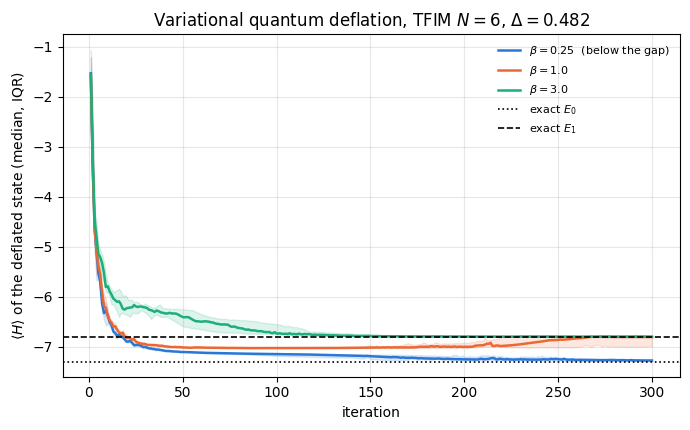

In [17]:
# ==============================================================================
# STEP 14: deflation for the first excited state of the critical Ising chain
# ==============================================================================
i_best = int(np.argmin(HIST[i_tfim, :, -1, 0]))
theta_star = TH_FINAL[i_tfim][i_best]
psi_star = ansatz_state(theta_star)
E_star = float(energy(model_terms(N_SITES, c_tfim), psi_star))
print(f"deflation anchor: best VQE ground state of the TFIM, E = {E_star:.6f} "
      f"(exact E_0 = {EXACT['TFIM']['E0']:.6f}, error {E_star - EXACT['TFIM']['E0']:.2e}), "
      f"F = {float(fidelity_pure(psi0_tfim, psi_star)):.4f}")
gap_tfim = EXACT["TFIM"]["E1"] - EXACT["TFIM"]["E0"]
print(f"exact gap Delta = {gap_tfim:.6f};  Eq. (12) requires beta > Delta")

R_VQD, T_VQD = 12, 300
th_v, ks_v = random_starts(R_VQD, n_main, seed=61)
BETAS = (0.25, 1.0, 3.0)


def vqd_run(beta):
    """Train R_VQD restarts on the deflated cost, Eq. (11); monitor (E of the state, overlap with psi_star)."""
    def cost(t):
        psi = ansatz_state(t)
        return energy(model_terms(N_SITES, c_tfim), psi) + beta * fidelity_pure(psi_star, psi)

    def monitor(t):
        psi = ansatz_state(t)
        return jnp.stack([energy(model_terms(N_SITES, c_tfim), psi), fidelity_pure(psi_star, psi),
                          fidelity_pure(EXACT["TFIM"]["psi1"], psi), parity(psi)])

    return jax.vmap(lambda t, k: train(t, k, grad_exact(cost), opt_adam(LR_BEST), monitor, T_VQD)[1])(th_v, ks_v)


print(f"\n{'beta':>6s} {'beta > gap?':>12s} {'median E':>10s} {'best E':>10s} {'exact E_1':>10s} "
      f"{'median overlap':>15s} {'median F with |1>':>18s} {'median parity':>14s}")
vqd_hist = {}
for beta in BETAS:
    h = np.asarray(jax.block_until_ready(jax.jit(vqd_run)(beta)))
    vqd_hist[beta] = h
    print(f"{beta:6.2f} {str(beta > gap_tfim):>12s} {np.median(h[:, -1, 0]):10.5f} {h[:, -1, 0].min():10.5f} "
          f"{EXACT['TFIM']['E1']:10.5f} {np.median(h[:, -1, 1]):15.2e} {np.median(h[:, -1, 2]):18.4f} "
          f"{np.median(h[:, -1, 3]):+14.4f}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
for j, beta in enumerate(BETAS):
    lo, med, hi = bands(vqd_hist[beta][:, :, 0])
    ax.fill_between(np.arange(1, T_VQD + 1), lo, hi, color=PALETTE[j], alpha=0.15)
    ax.plot(np.arange(1, T_VQD + 1), med, "-", lw=1.8, color=PALETTE[j],
            label=fr"$\beta={beta}$" + ("" if beta > gap_tfim else "  (below the gap)"))
ax.axhline(EXACT["TFIM"]["E0"], color="k", ls=":", lw=1.2, label=r"exact $E_0$")
ax.axhline(EXACT["TFIM"]["E1"], color="k", ls="--", lw=1.2, label=r"exact $E_1$")
ax.set_xlabel("iteration"); ax.set_ylabel(r"$\langle H\rangle$ of the deflated state (median, IQR)")
ax.set_title(f"Variational quantum deflation, TFIM $N={N_SITES}$, $\\Delta={gap_tfim:.3f}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Equation (12) is a sharp threshold, and the run below it fails in the predicted way.** With $\beta=0.25<\Delta$
the deflated minimisation returns the *ground* state again: median energy $-7.276$, median overlap with the anchor
$0.994$, fidelity with the exact first excited state $0.0003$, parity $+0.998$. The penalty is simply not large
enough to lift $E_0+\beta$ above $E_1$, so the minimiser of Eq. (11) is still the ground state, exactly as the
derivation says.

**Above the threshold it works.** With $\beta=3$ the median energy is $-6.7998$ against the exact
$E_1=-6.81408$ — an error of $0.014$ — the median overlap with the anchor has fallen to $1.1\cdot10^{-3}$, the median
fidelity with the true first excited state is $0.993$, and the parity is $-0.9925$. The method has not only found
the first excited energy, it has found it in the **odd** parity sector, which is where the exact $\vert\psi_1\rangle$
lives (Section 11's table). Nothing in the algorithm was told about parity.

**An approximate anchor leaks, and the leak is measurable.** At $\beta=1$ the best single run reports
$E=-7.024$, which is *below* $E_1=-6.814$. That is not a bug and not a violation of anything: the
derivation of Eq. (12) assumed $\vert\psi_\star\rangle=\vert\psi_0\rangle$ exactly, whereas our anchor is a
variational state with $F=0.9987$, so a trial state can be orthogonal to $\vert\psi_\star\rangle$ and still retain a
component along the true $\vert\psi_0\rangle$ — which drags the energy down towards $E_0$. The measured parity of
that run, $-0.911$ rather than $-1$, shows the contamination directly. Raising $\beta$ to $3$ suppresses the residual
overlap by a further factor of $30$ and pushes the best run to $-6.81085$, now safely above $E_1$. **In deflation the
error of the anchor propagates into the excited state, and the only protection is a large penalty and a good anchor.**

## 13. Shot noise: SPSA against parameter shift at equal measurement budget

On hardware the energy is not evaluated, it is **estimated** from a finite number of projective measurements. For the
transverse-field Ising Hamiltonian two measurement settings suffice, because the $Z$-type terms all commute with one
another and so do the $X$-type terms (notebook 40, Section 12): measure every qubit in $Z$ to get all
$\langle Z_qZ_{q+1}\rangle$ at once, and every qubit in $X$ to get all $\langle X_q\rangle$ at once. With $M$ shots
split evenly, the estimator is unbiased with variance $\propto1/M$.

The comparison that matters is at **equal total number of shots**, not at equal iteration count. Notebook 41 compared
the two gradient rules at equal iterations and found parameter shift ahead; it also said plainly that this does not
answer the budget question. Here we answer it. With $n$ angles,

* a parameter-shift iteration costs $2n$ circuits, hence $2nM$ shots;
* an SPSA iteration costs $2$ circuits, hence $2M$ shots.

At a fixed total budget $B$ the parameter-shift method may take $T_{\text{PS}}=B/(2nM)$ iterations and SPSA may take
$T_{\text{SPSA}}=n\,T_{\text{PS}}$ — a factor $n$ more steps with the same shots. The question is whether many cheap
noisy steps beat few accurate ones. The diagnostic plotted is always the **exact** energy error of the current
angles, which the optimiser never sees.

In [18]:
# ==============================================================================
# STEP 15: shot-noise estimators for the Ising energy (N = 4)
# ==============================================================================
N_SN, L_SN, H_SN, JZZ_SN = 4, 2, 1.0, -1.0
n_sn = hea_num_params(N_SN, L_SN)
c_sn = jnp.asarray((0.0, 0.0, JZZ_SN, H_SN), dtype=RDTYPE)
terms_sn = model_terms(N_SN, c_sn)
E0_SN, _ = lanczos_ground_state(terms_sn, N_SN)
E0_SN_dense = float(np.min(np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms_sn, N_SN)))))
print(f"TFIM N={N_SN}, h={H_SN}: E_0 = {E0_SN:.9f} (Lanczos) vs {E0_SN_dense:.9f} (dense), "
      f"difference {abs(E0_SN - E0_SN_dense):.1e}")
assert abs(E0_SN - E0_SN_dense) < 1e-8


def energy_shots(key, psi, shots):
    """Unbiased estimate of <H_TFIM> from `shots` projective measurements, Eq. (6) with Jxx=Jyy=0.

    PROTOCOL  half the shots measure every qubit in Z (all Z_q Z_{q+1} at once), half in X (all X_q at once).
    IMPL      `sample_bitstrings` returns bits of shape (shots, N); z = 1 - 2*bit are the +-1 eigenvalues.
    COST      2 circuit executions of shots/2 repetitions each.
    """
    kz, kx = jax.random.split(key)
    half = shots // 2
    z = 1.0 - 2.0 * sample_bitstrings(kz, psi, half, bases="Z" * N_SN).astype(RDTYPE)
    x = 1.0 - 2.0 * sample_bitstrings(kx, psi, half, bases="X" * N_SN).astype(RDTYPE)
    return JZZ_SN * jnp.mean(jnp.sum(z[:, :-1] * z[:, 1:], axis=1)) + H_SN * jnp.mean(jnp.sum(x, axis=1))


# --- CHECKPOINT: the shot estimator is unbiased and its spread falls as M^{-1/2} -------------------
theta_chk = random_starts(1, n_sn, seed=71)[0][0]
psi_chk = hardware_efficient_ansatz(theta_chk, N_SN, L_SN)
E_chk = float(energy(terms_sn, psi_chk))
print(f"\nexact <H> at a random parameter vector = {E_chk:.6f}")
print(f"{'shots M':>9s} {'mean of 300 estimates':>23s} {'measured std':>14s} {'std x sqrt(M)':>15s}")
for M in (32, 128, 512, 2048):
    ests = np.asarray(jax.vmap(lambda k: energy_shots(k, psi_chk, M))(jax.random.split(jax.random.PRNGKey(73), 300)))
    print(f"{M:9d} {ests.mean():23.5f} {ests.std():14.5f} {ests.std() * np.sqrt(M):15.5f}")
    assert abs(ests.mean() - E_chk) < 6 * ests.std() / np.sqrt(300)

TFIM N=4, h=1.0: E_0 = -4.758770483 (Lanczos) vs -4.758770483 (dense), difference 0.0e+00



exact <H> at a random parameter vector = 0.723708
  shots M   mean of 300 estimates   measured std   std x sqrt(M)


       32                 0.73792        0.57310         3.24196


      128                 0.71198        0.28079         3.17680


      512                 0.70852        0.14919         3.37571


     2048                 0.72068        0.07171         3.24506


equal budget B = 184320 shots per run:
  parameter shift + Adam : 60 iterations x 48 circuits x 64 shots
  SPSA + Adam            : 1440 iterations x 2 circuits x 64 shots


  (four training batches in 10.7 s)



                      method  iterations   shots used   median final E-E_0       best
      parameter shift + Adam          60       184320              0.32949    0.20756
                 SPSA + Adam        1440       184320              1.29703    0.66400
 parameter shift, exact cost          60            0              0.20385    0.06694
            SPSA, exact cost        1440            0              0.62882    0.26748
  exact gradient, 2000 iters        2000            0              0.00149    0.00148
(the last row is the ansatz floor: what this circuit family can do at N=4, L=2 with no budget limit)


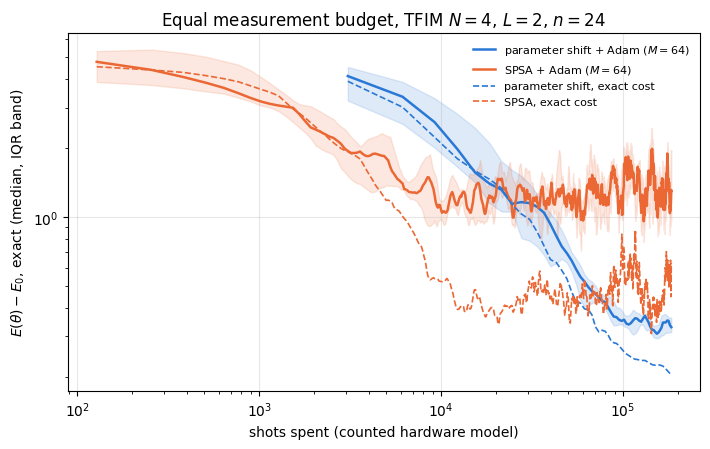

In [19]:
# ==============================================================================
# STEP 16: the two gradient rules with shots, and the equal-budget comparison
# ==============================================================================
def grad_ps_shots(M):
    """Parameter-shift gradient in which each of the 2n circuits is estimated from M shots (notebook 40, Eq. (18))."""
    eye = jnp.eye(n_sn)

    def rule(theta, key, k):
        kp, km = jax.random.split(key)

        def one(e, k1, k2):
            cp = energy_shots(k1, hardware_efficient_ansatz(theta + (jnp.pi / 2) * e, N_SN, L_SN), M)
            cm = energy_shots(k2, hardware_efficient_ansatz(theta - (jnp.pi / 2) * e, N_SN, L_SN), M)
            return (cp - cm) / 2
        return jax.vmap(one)(eye, jax.random.split(kp, n_sn), jax.random.split(km, n_sn))
    return rule


def grad_spsa_shots(M, c=0.2, gamma=0.101):
    """SPSA gradient rule with both circuits estimated from M shots."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        kd, kp, km = jax.random.split(key, 3)
        delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
        cp = energy_shots(kp, hardware_efficient_ansatz(theta + c_k * delta, N_SN, L_SN), M)
        cm = energy_shots(km, hardware_efficient_ansatz(theta - c_k * delta, N_SN, L_SN), M)
        return (cp - cm) / (2 * c_k) * delta
    return rule


err_sn = jax.jit(lambda t: energy(terms_sn, hardware_efficient_ansatz(t, N_SN, L_SN)) - E0_SN)
R_SN, M_SN, T_PS = 8, 64, 60
T_SPSA = n_sn * T_PS                                   # same total shots: 2 n M T_PS  =  2 M T_SPSA
BUDGET = 2 * n_sn * M_SN * T_PS
th_sn, ks_sn = random_starts(R_SN, n_sn, seed=81)
print(f"equal budget B = {BUDGET} shots per run:")
print(f"  parameter shift + Adam : {T_PS} iterations x {2 * n_sn} circuits x {M_SN} shots")
print(f"  SPSA + Adam            : {T_SPSA} iterations x 2 circuits x {M_SN} shots")

t0 = time.perf_counter()
_, h_ps = train_many(th_sn, ks_sn, grad_ps_shots(M_SN), opt_adam(0.1), err_sn, T_PS)
_, h_sp = train_many(th_sn, ks_sn, grad_spsa_shots(M_SN), opt_adam(0.1), err_sn, T_SPSA)
_, h_ps_ex = train_many(th_sn, ks_sn, grad_exact(lambda t: energy(terms_sn, hardware_efficient_ansatz(t, N_SN, L_SN))),
                        opt_adam(0.1), err_sn, T_PS)
_, h_sp_ex = train_many(th_sn, ks_sn,
                        grad_spsa(lambda t: energy(terms_sn, hardware_efficient_ansatz(t, N_SN, L_SN)), c=0.2),
                        opt_adam(0.1), err_sn, T_SPSA)
h_ps, h_sp = np.asarray(h_ps), np.asarray(h_sp)
h_ps_ex, h_sp_ex = np.asarray(h_ps_ex), np.asarray(h_sp_ex)
print(f"  (four training batches in {time.perf_counter() - t0:.1f} s)")

_, h_floor = train_many(th_sn, ks_sn,
                        grad_exact(lambda t: energy(terms_sn, hardware_efficient_ansatz(t, N_SN, L_SN))),
                        opt_adam(0.1), err_sn, 2000)
h_floor = np.asarray(h_floor)

print(f"\n{'method':>28s} {'iterations':>11s} {'shots used':>12s} {'median final E-E_0':>20s} {'best':>10s}")
for lab, h, T, sh in (("parameter shift + Adam", h_ps, T_PS, BUDGET),
                      ("SPSA + Adam", h_sp, T_SPSA, BUDGET),
                      ("parameter shift, exact cost", h_ps_ex, T_PS, 0),
                      ("SPSA, exact cost", h_sp_ex, T_SPSA, 0),
                      ("exact gradient, 2000 iters", h_floor, 2000, 0)):
    print(f"{lab:>28s} {T:11d} {sh if sh else 0:12d} {np.median(h[:, -1]):20.5f} {h[:, -1].min():10.5f}")
print(f"(the last row is the ansatz floor: what this circuit family can do at N={N_SN}, L={L_SN} with no budget limit)")

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for j, (lab, h, T) in enumerate((("parameter shift + Adam", h_ps, T_PS), ("SPSA + Adam", h_sp, T_SPSA))):
    shots_axis = np.arange(1, T + 1) * (2 * n_sn * M_SN if j == 0 else 2 * M_SN)
    lo, med, hi = bands(np.maximum(h, 1e-12))
    ax.fill_between(shots_axis, lo, hi, color=PALETTE[j], alpha=0.15)
    ax.loglog(shots_axis, med, "-", lw=1.8, color=PALETTE[j], label=lab + f" ($M={M_SN}$)")
for j, (lab, h, T) in enumerate((("parameter shift, exact cost", h_ps_ex, T_PS), ("SPSA, exact cost", h_sp_ex, T_SPSA))):
    shots_axis = np.arange(1, T + 1) * (2 * n_sn * M_SN if j == 0 else 2 * M_SN)
    _, med, _ = bands(np.maximum(h, 1e-12))
    ax.loglog(shots_axis, med, "--", lw=1.2, color=PALETTE[j], label=lab)
ax.set_xlabel("shots spent (counted hardware model)")
ax.set_ylabel(r"$E(\theta)-E_0$, exact (median, IQR band)")
ax.set_title(f"Equal measurement budget, TFIM $N={N_SN}$, $L={L_SN}$, $n={n_sn}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**The estimator behaves.** Its mean over 300 repetitions tracks the exact energy at every budget, and the product
std $\times\sqrt M$ is constant at $3.2$ to $3.4$ across a factor of $64$ in $M$ — the $M^{-1/2}$ law, with the
constant being the single-shot standard deviation of the two-setting protocol.

**At equal measurement budget, parameter shift wins this comparison.** With $B=184320$ shots per run, spent either
as $60$ accurate iterations or as $1440$ cheap ones, the median final energy error is $0.329$ for parameter shift
and $1.297$ for SPSA — a factor of four. The $24$-fold advantage in iteration count did not compensate for using one
scalar of information per step instead of $n=24$.

**But the shots are not the main obstacle.** The two exact-cost references, run with identical optimisers and
identical iteration counts, give $0.204$ and $0.629$. So of SPSA's final $1.297$, the part attributable to shot noise
is roughly a factor of two; the rest is the method. The ranking between the two gradient rules is essentially the
same with and without noise, which means this experiment measures the optimisers more than it measures the
estimator — a conclusion only available because the noise-free references were run.

**Both are far from the ansatz floor.** With an exact gradient and a generous $2000$ iterations the same circuit
reaches $1.5\cdot10^{-3}$, two orders of magnitude below what either method achieved with $1.8\cdot10^{5}$ shots.
The gap between $1.5\cdot10^{-3}$ and $0.2$ is the price of the measurement budget, and it is the quantity that
[43 — VQE with classical shadows](../ch11_variational_quantum_circuits/43_vqe_with_classical_shadows.ipynb) attacks
from the estimator side.

> **Numerical practice.** Every curve here is the **exact** energy error of the current angles, a quantity the
> optimiser never sees. Plotting the noisy estimate instead produces a curve that dips below the true value by about
> one standard error and makes every method look better than it is. A real experiment must re-measure its final
> answer with a much larger budget than it used during training.

## 14. Honest limits

Everything above was run on a simulator with $N\le6$ spins, where the exact answer is one Lanczos call away. Four
limits decide whether any of it scales.

**Barren plateaus.** Notebook 40 measured that the variance of one gradient component of a hardware-efficient circuit
over random angles decays as $2^{-\beta N}$, with $\beta\approx1.8$ for a global cost and $\beta\approx0.6$ for a local
one. An energy is a sum of $O(N)$ local terms, so it is on the favourable side of that dichotomy, but the decay is
still exponential, and a gradient that is exponentially small must be resolved above shot noise that falls only as
$M^{-1/2}$. The remedy has to change the ansatz or the cost, not the optimiser (McClean *et al.*, 2018; Cerezo
*et al.*, 2021). The random-angle initialisation used throughout this notebook is precisely the distribution the
plateau theorems assume.

**Measurement cost.** Every energy evaluation here was exact and free. On hardware, an accuracy $\varepsilon$ on
$\langle H\rangle$ costs $O(\lVert\mathbf c\rVert_1^2/\varepsilon^2)$ shots, and chemistry-scale Hamiltonians have
$O(N^4)$ terms. A single Adam iteration with a parameter-shift gradient costs $2n$ circuit families, each needing that
many shots. This is the dominant practical obstacle, and it is the subject of
[43 — VQE with classical shadows](../ch11_variational_quantum_circuits/43_vqe_with_classical_shadows.ipynb).

**Noise.** Real gates are imperfect, which biases the energy upwards and deforms the landscape; the variational
principle still guarantees $E\ge E_0$ for the *measured* state, but the measured state is mixed and the bound becomes
uninformative.

**What classical methods do better for these problems.** For a one-dimensional gapped chain the ground state obeys an
area law, and a matrix-product state with modest bond dimension represents it to machine precision; DMRG finds it in
seconds for hundreds of sites, far beyond anything demonstrated variationally on hardware
([18 — MPS and TEBD](../ch07_tensor_networks/18_mps_tebd.ipynb)). The honest statement is that VQE on a spin chain is a
*benchmark*, not an application: it is the setting in which the algorithm can be validated against an exact answer,
which is exactly what this notebook did. The regimes where no good classical method exists — frustrated
two-dimensional magnets, real-time dynamics, strongly correlated chemistry — are also the regimes where the ansatz
design and the measurement cost are hardest.

## 15. Key takeaways

* **The variational principle is proved in three lines and works as a unit test.** Every trial state satisfies
  $\langle H\rangle\ge E_0$, Eq. (1). Across the $10800$ energies recorded in Section 8 the error never went
  negative, its smallest value being $1.6\cdot10^{-3}$; a negative value would have exposed an inconsistency between
  the ansatz, the Hamiltonian and the reference.
* **The energy error is second order in the state error.** Equation (2) predicts $E-E_0\propto\varepsilon^2$, and the
  measured ratio $(E-E_0)/\varepsilon^2$ was constant at $7.20964$ over four decades. A state that is wrong at the
  $1\%$ level gives an energy that is right to five digits.
* **The gap converts an energy error into a certificate on the state**, $1-F\le(E-E_0)/\Delta$, Eq. (5), with the
  companion upper bound $(E_{\max}-E_0)(1-F)$; the two differ by a factor $30$ for the critical Ising chain. Where
  the gap closes the certificate says nothing, and Section 11 measured a field at which it degenerates to
  $1-F\le1$.
* **Signs in the Pauli convention must be read off the correlators.** With $J_{xx}=-1$ the measured
  $\langle X_iX_{i+1}\rangle=+0.98$: the coupling is ferromagnetic along $x$. The scope's XXZ and XY parameters put
  those chains in a nearly polarised phase with $0.05$ and $0.12$ bits of entanglement, while the Ising chain at
  $h_x=1$ sits at its critical point with $0.47$ bits and a six times smaller gap.
* **The Hamiltonians have a $\mathbb Z_2$ parity $P=\prod_qX_q$ and no $U(1)$.** The measured
  $\lVert[H,P]\vert\phi\rangle\rVert$ was exactly zero, and $\lVert[H,S^z_{\text{tot}}]\vert\phi\rangle\rVert=4.41$ —
  the same number for all three models, because the whole commutator comes from the transverse field. Switching the
  field off restored the $U(1)$ to $8.5\cdot10^{-16}$.
* **The hardware-efficient ansatz breaks the symmetry and then partly relearns it.** At random angles the median
  symmetry leakage $1-\lvert\langle P\rangle\rvert$ was $0.94$; after training, $5\cdot10^{-4}$ to
  $1.2\cdot10^{-3}$, correlated with the energy error. The Hamiltonian-variational ansatz has leakage
  $2.7\cdot10^{-15}$ at *any* angles — a proof, not a fit.
* **Depth helps only where the family is the limitation.** The critical Ising error fell from $0.213$ ($L=1$) to
  $0.0094$ ($L=6$), while the polarised chains stopped improving after $L=2$. The entanglement produced always
  approached the exact value **from below** ($0.43$ against $0.47$ bits at $L=4$), which is the signature of an
  under-expressive circuit — visible even when the energy looks converged.
* **The entanglement bound $S_{\text{half}}\le L$ is necessary, not sufficient.** At $L=1$ the circuit may carry one
  bit and the target needs $0.47$, yet the optimised state carried $0.013$ bits and missed the energy by $0.21$. All
  depths studied had $n\le84$ against the $2\cdot2^N-2=126$ parameters of a general state, so the
  overparametrisation threshold of notebook 41 was never crossed — a ground state is structured enough not to need
  it.
* **Problem-inspired structure is worth a large factor in parameters and costs a rougher landscape.** At equal
  depth the hardware-efficient family wins; at $16$ angles the Hamiltonian-variational family reached a median of
  $0.075$ and a best run of $0.0071$ where a $24$-angle hardware-efficient circuit managed $0.213$. Its
  median-to-best spread was a factor of thirty across restarts, against two for the other family.
* **In the ordered phase, fidelity with "the" ground state is the wrong question.** At $h=0.2$ the VQE reached an
  energy error of $2\cdot10^{-4}$ with fidelity exactly $0.5000$ — and fidelity $0.9999$ with the two-dimensional
  doublet. The measured entropy ($0.0001$ bits) and parity ($0.000$) identify the solution as a symmetry-broken
  ferromagnetic configuration. The hardest field of the sweep was $h=0.8$, not the critical point.
* **Deflation turns a minimiser into an excited-state solver, above a threshold.** Eq. (12) requires $\beta>\Delta$;
  at $\beta=0.25<\Delta=0.482$ the method returned the ground state again, at $\beta=3$ it returned
  $E_1$ to $0.014$ with fidelity $0.993$ and parity $-0.99$. An approximate anchor leaks: at $\beta=1$ one run
  reported an energy *below* $E_1$, with a parity of $-0.91$ betraying the residual ground-state component.
* **At equal measurement budget the parameter-shift gradient beat SPSA** ($0.329$ against $1.297$), but the
  noise-free references ($0.204$ and $0.629$) show that most of the difference is the optimiser, not the shots — and
  both are two orders of magnitude above the $1.5\cdot10^{-3}$ that the same circuit reaches with an unlimited
  budget.

## 16. Exercises

1. ★ **The bound in action.** Take the converged TFIM run of Section 8 and compute the certified infidelity bound
   $1-F\le(E-E_0)/\Delta$ of Eq. (5) from the measured energy error alone. Compare with the true infidelity. By what
   factor is the certificate loose, and why?
2. ★ **Antiferromagnetic couplings.** Flip the sign of $J_{xx}$ and $J_{yy}$ in the XXZ model. Predict the sign of
   $\langle X_iX_{i+1}\rangle$ in the exact ground state before you run it, then check. Does the VQE find it as easily?
3. ★★ **A symmetry-preserving ansatz (extend the code).** Replace the $R_y,R_z$ rotation blocks by $R_x$ rotations and
   the $CZ$ entanglers by $R_{XX}(\theta)$ gates, starting from $\vert+\rangle^{\otimes N}$. Show analytically that
   every gate commutes with $P=\prod_qX_q$, so the symmetry leakage of Eq. (8) is zero by construction, and measure
   whether the energy error at equal parameter count is better or worse.
4. ★★ **The Hamiltonian-variational ansatz (extend the code).** Import `hva_tfim` from notebook 40 (it has $2L$ angles
   instead of $2N(L+1)$) and repeat Section 10 for the critical Ising chain. At equal *parameter count*, which family
   reaches the lower energy? At equal *depth*?
5. ★★ **Deflation to the second excited state.** Extend Eq. (11) with a second penalty term
   $\beta_1\lvert\langle\psi_1^\star\vert\psi\rangle\rvert^2$ and find $E_2$. Derive the condition on the two penalties
   analogous to Eq. (12) and verify it numerically by scanning $\beta$.
6. ★★ **Where does the sweep get hard? (physics)** Repeat Section 11 for $N=8$ and $N=10$ at fixed $L$. Does the peak
   of the energy error follow the critical point, and does the width of the difficult region shrink with $N$?
7. ★★★ **Order parameter without symmetry breaking (physics).** In the ordered phase the magnetisation
   $\langle Z_q\rangle$ vanishes in the exact finite-$N$ ground state even though the system is ordered. Compute the
   correlator $\langle Z_0Z_{N-1}\rangle$ instead, for the exact state and for the VQE states of Section 11, and
   explain why it is the right diagnostic there.
8. ★★★ **The shot budget of the whole calculation (physics).** From Section 13, extrapolate the number of shots needed
   to reach a chemical-accuracy energy error ($1.6\cdot10^{-3}$ Hartree, here read as $10^{-3}$ in units of $J$) for
   $N=6$ with $L=4$. Combine with the barren-plateau exponents of notebook 40 to estimate how that budget grows with
   $N$, and say at which $N$ it exceeds a day of machine time.

## References

* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first VQE
  experiment.
* J. R. McClean, J. Romero, R. Babbush and A. Aspuru-Guzik, *The theory of variational hybrid quantum-classical
  algorithms*, New J. Phys. **18**, 023023 (2016) — the general framework, and the variational principle in this
  setting.
* A. Kandala, A. Mezzacapo, K. Temme, M. Takita, M. Brink, J. M. Chow and J. M. Gambetta, *Hardware-efficient
  variational quantum eigensolver for small molecules and quantum magnets*, Nature **549**, 242 (2017) — the ansatz
  used here.
* D. Wecker, M. B. Hastings and M. Troyer, *Progress towards practical quantum variational algorithms*, Phys. Rev. A
  **92**, 042303 (2015) — the Hamiltonian-variational ansatz.
* W. W. Ho and T. H. Hsieh, *Efficient variational simulation of non-trivial quantum states*, SciPost Phys. **6**, 029
  (2019) — problem-inspired ansätze for spin chains, including the transverse-field Ising model.
* O. Higgott, D. Wang and S. Brierley, *Variational quantum computation of excited states*, Quantum **3**, 156 (2019)
  — variational quantum deflation, Eq. (11) and the condition of Eq. (12).
* J. Tilly, H. Chen, S. Cao, D. Picozzi, K. Setia, Y. Li, E. Grant, L. Wossnig, I. Rungger, G. H. Booth and
  J. Tennyson, *The variational quantum eigensolver: a review of methods and best practices*, Phys. Rep. **986**, 1
  (2022) — the comprehensive review.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — ansatz design,
  trainability and barren plateaus.
* J. R. McClean, S. Boixo, V. N. Smelyanskiy, R. Babbush and H. Neven, *Barren plateaus in quantum neural network
  training landscapes*, Nat. Commun. **9**, 4812 (2018) — the exponential concentration of gradients.
* M. Larocca, N. Ju, D. García-Martín, P. J. Coles and M. Cerezo, *Theory of overparametrization in quantum neural
  networks*, Nat. Comput. Sci. **3**, 542 (2023) — the parameter-count threshold used in Section 10.2.
* S. Sachdev, *Quantum Phase Transitions*, 2nd ed., Cambridge University Press (2011) — the transverse-field Ising
  chain, its critical point and the symmetry-broken doublet of Section 11.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/